# Import libraries

In [1]:
# %pip install tensorly numpy matplotlib torch tqdm h5py scikit-image scikit-learn pandas
# %pip install --upgrade scikit-image

In [2]:
# Standard library imports
from pathlib import Path

# Third-party imports
import numpy as np
import tensorly as tl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from PIL import Image

# Local TBMD module imports
from TBMD.modules.TensorHOSVD import TuckerDecomposer
from TBMD.modules.TensorTimeInsensitiveModes import (
    BatchModalProcessor, 
    ModalTensorStacker, 
    ModalProcessorConfig, 
    ProcessingStrategy,
    stack_all_modes, 
    process_all_subjects
)
from TBMD.modules.TensorBasedTubeFiberPivotQRFactorization import (
    TensorTubeQRDecomposition,
    TensorQRConfig
)

# from TBMD.modules.TensorBasedCompressiveSensing import (
#     TensorCompressiveSensing,
#     CompressiveSensingConfig,
# )

from TBMD.modules.TensorBasedCompressiveSensing import (
    TensorCompressiveSensing,
    CompressiveSensingConfig,
    ExtensionCompressiveSensingConfig
)

# TBMD utilities imports
from TBMD.utils.utils import (
    reconstruct_tensor, 
    build_Y_matrices, 
    to_torch_tensor, 
    generate_noisy_datasets,
    build_wells_matrix
)
from TBMD.utils.plots import (
    plot_two_matrices,
    plot_original_reconstructed_diff, 
    visualize_wells_placement, 
    visualize_tensor,
)
from TBMD.utils.metrics import compute_metrics
from TBMD.utils.process_data import (
    process_data, 
    calculate_global_minmax_params, 
    calculate_global_zscore_params, 
    inverse_normalization
)
from TBMD.utils.split_data import split_data_in_memory_ordered, split_data_in_memory
from TBMD.utils.Analytics import (
    ExperimentConfig,
    ExperimentRunner, 
    plot_analytics
)
from TBMD.utils.DataLoader import DataLoader
from TBMD.config import SEED, SET_BACKEND

In [3]:
SEED = 0

tl.check_random_state(SEED)
np.random.seed(SEED)

tl.set_backend(SET_BACKEND)

torch.set_printoptions(precision=4, sci_mode=False)

# Download data

In [4]:
loader = DataLoader()

### Load Brugge data

(x,y, variants_geo, count_var, timestemp)

In [5]:
tensors = DataLoader.load_h5_tensors("/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/Brugge data/data_exp_4_.h5")
wells = DataLoader.load_wells_from_json("/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/Brugge data/all_wells_exp_4.json")

In [6]:
for case_id in wells:
    # wells[case_id] is a list of [x,y] coordinate pairs.
    # This list comprehension iterates through each pair [x,y]
    # and creates a new pair [y,x], effectively swapping them.
    # The new list of swapped pairs replaces the original list for that case_id.
    wells[case_id] = [[x, y] for x, y in wells[case_id]]

# Display the modified wells dictionary
wells

{'case1': [[54, 27],
  [81, 28],
  [46, 34],
  [64, 36],
  [82, 32],
  [75, 41],
  [104, 31],
  [95, 44],
  [103, 39],
  [62, 26],
  [52, 45],
  [90, 32],
  [71, 37],
  [81, 43],
  [31, 43],
  [71, 28],
  [69, 45],
  [37, 38],
  [42, 45],
  [61, 45],
  [96, 36],
  [91, 27],
  [100, 44],
  [74, 33],
  [98, 34],
  [66, 41],
  [55, 37],
  [111, 42],
  [51, 42],
  [44, 41]],
 'case10': [[54, 27],
  [81, 28],
  [46, 34],
  [64, 36],
  [82, 32],
  [75, 41],
  [104, 31],
  [95, 44],
  [103, 39],
  [62, 26],
  [52, 45],
  [90, 32],
  [71, 37],
  [81, 43],
  [31, 43],
  [71, 28],
  [69, 45],
  [37, 38],
  [42, 45],
  [61, 45],
  [96, 36],
  [91, 27],
  [100, 44],
  [74, 33],
  [98, 34],
  [66, 41],
  [55, 37],
  [111, 42],
  [51, 42],
  [44, 41]],
 'case2': [[54, 27],
  [81, 28],
  [46, 34],
  [64, 36],
  [82, 32],
  [75, 41],
  [104, 31],
  [95, 44],
  [103, 39],
  [62, 26],
  [52, 45],
  [90, 32],
  [71, 37],
  [81, 43],
  [31, 43],
  [71, 28],
  [69, 45],
  [37, 38],
  [42, 45],
  [61, 45],


In [7]:
train_data, test_data = split_data_in_memory_ordered(tensors['all'], train_ratio=0.8)

subject_name = list(tensors['all'].keys())[0]

print(list(tensors['all'].keys()))
print(tensors['all'][subject_name].shape)

Experiments processed: 100%|██████████| 10/10 [00:00<00:00, 2539.39it/s]

['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10']
(139, 48, 2, 133)


In [8]:
# train_data, test_data = split_data_in_memory_ordered(tensors['pressure'], train_ratio=0.8)

# subject_name = list(tensors['pressure'].keys())[2]

# print(list(tensors['pressure'].keys()))
# print(tensors['pressure'][subject_name].shape)

In [9]:
# train_data, test_data = split_data_in_memory_ordered(tensors['soil'], train_ratio=0.8)

# subject_name = list(tensors['soil'].keys())[0]

# print(list(tensors['soil'].keys()))
# print(tensors['soil'][subject_name].shape)

### Load static csv data

In [10]:
# # Load static tensor
# static_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW static data"), "static", (286, 105, 100), tensor_type="pt")

# noisy_datasets = generate_noisy_datasets(
#     data=static_data,
#     noise_level=0.1,
#     num_noisy_datasets=5,
#     experiment_id="001"
# )

# train_data, test_data = split_data_in_memory_ordered(noisy_datasets, train_ratio=0.8)

# subject_name = list(noisy_datasets.keys())[0]

# print(list(noisy_datasets.keys()))
# print(noisy_datasets[subject_name].shape)

### Load dynamic csv data

In [11]:
# # Load dynamic tensor
# dynamic_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW dynamic data"), "dynamic", (286, 105, 25, 253), tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(dynamic_data, train_ratio=0.8)

# subject_name = list(dynamic_data.keys())[0]

# print(list(dynamic_data.keys()))
# print(dynamic_data[subject_name].shape)

### Load images

In [12]:
# # Load images tensor
# images_data, subject_list = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/HW data/dynamic_png_new"), "images", tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(images_data, train_ratio=0.8)

# subject_name = subject_list[0]

# print(subject_list)
# print(images_data[subject_name].shape)

In [13]:
# num_experiments = 2
# experiments_data = split_data_in_memory(images_data, num_experiments=num_experiments, train_ratio=0.8)

# if 1 not in experiments_data:
#     raise KeyError("Experiment ID 1 does not exist in 'experiments_data'.")

# train_data = experiments_data[1].get("train", {})
# test_data = experiments_data[1].get("test", {})

# Process data

In [14]:
# Decide what counts as background (CT example)
BG = None        # Hounsfield Units for air

# 1.  Build masks once if you have them, otherwise just pass background_value
train_global_min, train_global_max = calculate_global_minmax_params(train_data,
                                                                    background_value=BG)
train_global_mean, train_global_std = calculate_global_zscore_params(train_data,
                                                                     background_value=BG)

# 2.  Pack the globals
minmax_params = {'min': train_global_min, 'max': train_global_max}
zscore_params = {'mean': train_global_mean, 'std': train_global_std}

print(minmax_params)
print(zscore_params)

{'min': 0.0, 'max': 171.8720422674243}
{'mean': 59.32182719004501, 'std': 77.23516314408401}


In [15]:
resize_shape = None
convert_to_grayscale = False
normalization_method = "minmax"  # "zscore" or "minmax"

print("Processing train data:")
train_tensors = process_data(
    train_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,                
    background_value=BG
)

print("\nProcessing test data:")
test_tensors = process_data(
    test_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,
    background_value=BG
)

num_images_train = {subject: tensor.shape[-1] for subject, tensor in train_tensors.items()}
num_images_test  = {subject: tensor.shape[-1] for subject, tensor in test_tensors.items()}

if num_images_train:
    min_train_images = min(num_images_train.values())
    print(f"\nMinimum number of images in train: {min_train_images}")
else:
    print("\nNo data available for analysis in train.")

if num_images_test:
    min_test_images = min(num_images_test.values())
    print(f"Minimum number of images in test: {min_test_images}")
else:
    print("No data available for analysis in test.")

Processing train data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 83.35it/s]


case1: (139, 48, 2, 106)
case2: (139, 48, 2, 106)
case3: (139, 48, 2, 106)
case4: (139, 48, 2, 106)
case5: (139, 48, 2, 106)
case6: (139, 48, 2, 106)
case7: (139, 48, 2, 106)
case8: (139, 48, 2, 106)
case9: (139, 48, 2, 106)
case10: (139, 48, 2, 106)

Processing test data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 291.11it/s]

case1: (139, 48, 2, 27)
case2: (139, 48, 2, 27)
case3: (139, 48, 2, 27)
case4: (139, 48, 2, 27)
case5: (139, 48, 2, 27)
case6: (139, 48, 2, 27)
case7: (139, 48, 2, 27)
case8: (139, 48, 2, 27)
case9: (139, 48, 2, 27)
case10: (139, 48, 2, 27)

Minimum number of images in train: 106
Minimum number of images in test: 27


# Visualization

In [16]:
def visualize_tensor(
    tensor,
    subject_name=None,
    save_path=None,
    cmap="gray",
    cols=5,
    show_colorbar=False,
    zmin=None,  # Add zmin parameter
    zmax=None,   # Add zmax parameter
    wells=None,  # Скважины для отображения
    frame_step=1  # Отображать каждый N-й кадр (по умолчанию каждый)
):
    """
    Visualizes a tensor of images. If the tensor is 3D (H, W, T), each (H, W) slice is 
    treated as a grayscale frame. If the tensor is 4D (H, W, C, T), each slice is treated 
    as a color image.
    
    Parameters:
      - tensor (numpy.ndarray): The data to visualize. Expected shapes:
          * (H, W, T) for grayscale images.
          * (H, W, C, T) for color images.
      - subject_name (str): Title label for the subject.
      - save_path (str): If provided, the path where the plot will be saved.
      - cmap (str): Matplotlib colormap used for imshow when displaying grayscale images.
      - cols (int): Number of columns in the grid layout.
      - show_colorbar (bool): Whether to display colorbars for each subplot.
      - zmin (float, optional): Minimum value for the color scale (vmin in imshow). 
                                If None, calculated per frame as the minimum non-zero value.
      - zmax (float, optional): Maximum value for the color scale (vmax in imshow).
                                If None, calculated per frame as the maximum value.
      - wells (dict or list): Координаты скважин. Может быть:
                             * dict с ключами = subject_name и значениями = списки координат [(x1, y1), ...]
                             * dict с ключами = subject_name и значениями = вложенные словари {frame_idx: [(x1, y1), ...], ...}
                             * простой список координат [(x1, y1), ...] для всех кадров
      - frame_step (int): Шаг для отображения кадров. При frame_step=10 будет отображаться каждый 10-й кадр.
    """
    # Ensure tensor has either 3 or 4 dimensions.
    if tensor.ndim not in (3, 4):
        raise ValueError(f"Expected tensor with 3 or 4 dimensions, got shape {tensor.shape}.")

    # Optional: Check pixel intensity range.
    # Note: This check might conflict with user-provided zmin/zmax. Consider adjusting or removing.
    # if tensor.min() < 0 or tensor.max() > 1:
    #     print("Warning: Tensor values are outside the range [0, 1]. Verify if correct.")

    # Determine the number of frames (T) and image shape.
    if tensor.ndim == 3:
        H, W, T = tensor.shape
    else:  # tensor.ndim == 4
        H, W, C, T = tensor.shape

    # Выбираем кадры с заданным шагом
    frame_indices = list(range(0, T, frame_step))
    selected_frames_count = len(frame_indices)

    # Determine the number of rows needed for the grid layout.
    rows = (selected_frames_count + cols - 1) // cols

    # Увеличиваем размер фигуры для более крупных subplots
    fig, axes = plt.subplots(rows, cols, figsize=(6.5 * cols, 6.5 * rows))
    
    # Handle case where rows=1 or cols=1, making axes not 2D
    if selected_frames_count <= 1:
        axes = np.array([axes]) # Ensure axes is always iterable
    axes = axes.flatten()  # Flatten axes array for easier iteration.

    for display_idx, ax in enumerate(axes):
        if display_idx < selected_frames_count:
            # Получаем реальный индекс кадра
            frame_idx = frame_indices[display_idx]
            
            # Extract the frame depending on tensor dimensions.
            if tensor.ndim == 3:
                frame = tensor[:, :, frame_idx]
                
                # Determine vmin and vmax for this frame
                current_zmin = zmin
                if current_zmin is None:
                    # Calculate min non-zero value, default to 0 if all zero
                    non_zero_frame = frame[frame != 0]
                    if non_zero_frame.size > 0:
                        current_zmin = non_zero_frame.min()
                    else:
                         current_zmin = 0 # Frame is all zeros

                current_zmax = zmax
                if current_zmax is None:
                    current_zmax = frame.max()
                    # Handle case where max is 0 (or less than min)
                    if current_zmax <= current_zmin and current_zmax == 0:
                         current_zmax = 1 # Avoid vmin=vmax=0 if possible, adjust as needed

                im = ax.imshow(frame, cmap=cmap, aspect="equal", vmin=current_zmin, vmax=current_zmax)
            else:  # 4D tensor: display color image.
                # vmin/vmax typically not used directly for RGB images with imshow
                frame = tensor[:, :, :, frame_idx]
                # Ensure frame data is in displayable range [0,1] or [0,255] if needed
                # frame = np.clip(frame, 0, 1) # Example clipping if data is float [0,1]
                im = ax.imshow(frame, aspect="equal") 
                
            ax.set_title(f"Frame {frame_idx + 1}", fontsize=20)
            
            # Отображение скважин
            if wells is not None:
                wells_to_plot = None
                # Определяем какие скважины отображать для данного subject/frame
                if subject_name is not None:
                    # Проверяем разные форматы wells
                    if isinstance(wells, dict):
                        wells_to_plot = wells.get(subject_name)
                        # Если wells[subject_name] - словарь с ключами-номерами кадров
                        if isinstance(wells_to_plot, dict):
                            wells_to_plot = wells_to_plot.get(frame_idx)
                        # Проверяем альтернативный ключ subject_name_frame_idx
                        elif wells_to_plot is None:
                            wells_to_plot = wells.get(f"{subject_name}_{frame_idx}")
                else:
                    # Если subject_name не указан, пытаемся использовать wells напрямую
                    if isinstance(wells, list) or (isinstance(wells, np.ndarray) and wells.ndim >= 2):
                        wells_to_plot = wells
                
                # Отображаем скважины, если нашли
                if wells_to_plot is not None and len(wells_to_plot) > 0:
                    wells_array = np.array(wells_to_plot)
                    
                    # Отображение скважин без масштабирования (координаты должны быть в пикселях)
                    ax.scatter(wells_array[:, 0], wells_array[:, 1], c='red', marker='o', s=80, label='Wells')
                    
                    ax.legend(loc='upper right', fontsize=18)
            
            if show_colorbar:
                 # For 3D tensors, colorbar uses calculated vmin/vmax
                 # For 4D tensors, colorbar might not be meaningful unless specific channel shown
                 if tensor.ndim == 3:
                     cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pressure, psi")
                     cbar.ax.tick_params(labelsize=16)
                     cbar.set_label("Pressure, psi", size=18)                 # else: # Optional: add colorbar logic for 4D if needed
                 #    pass 
        ax.axis("off")

    # Adjust title position if it exists and make layout more compact
    if subject_name:
        fig.suptitle(f"Subject: {subject_name}", fontsize=40)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent title overlap
        # Уменьшаем расстояние между изображениями для более компактного вида
        plt.subplots_adjust(wspace=0.001, hspace=0.15)
    else:
        plt.tight_layout()
        # Уменьшаем расстояние между изображениями для более компактного вида
        plt.subplots_adjust(wspace=0.001, hspace=0.15)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved visualization to: {save_path}")
        plt.close(fig)
    else:
        plt.show()

TypeError: Invalid shape (139, 48, 2) for image data

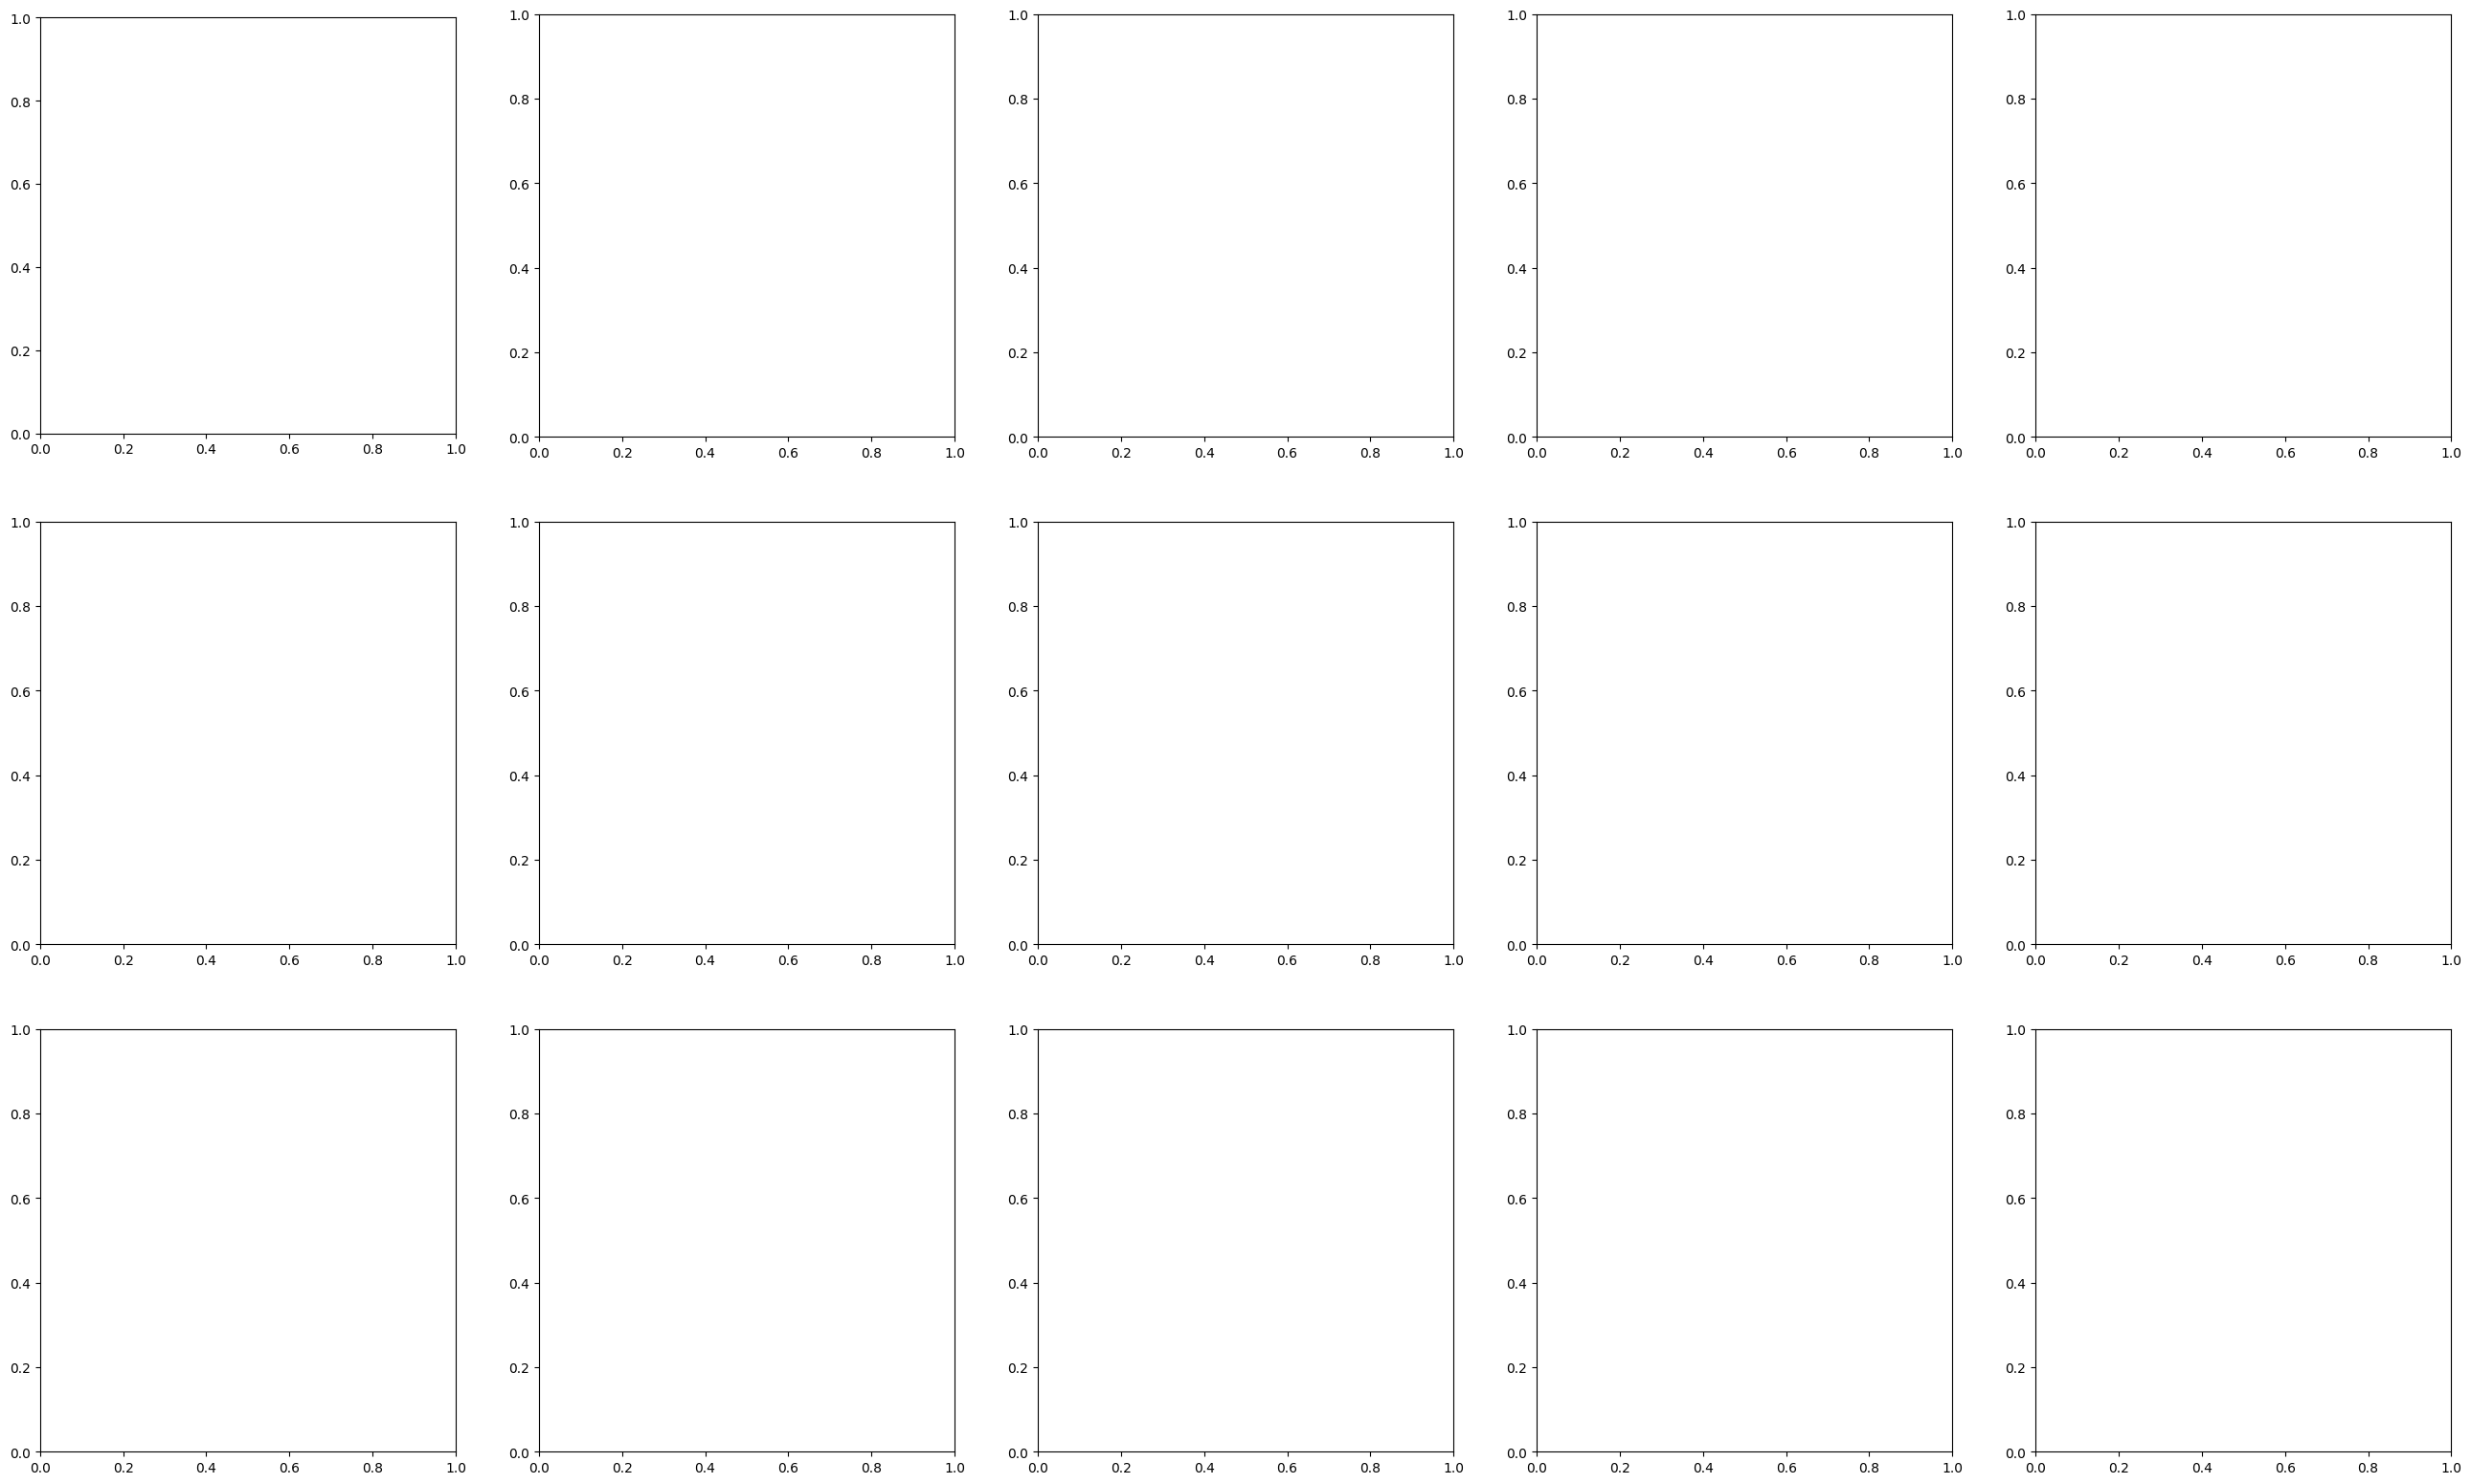

In [17]:
tensor = train_data[subject_name]
reversed_wells = {subject_name: [corr[::-1] for corr in well] for subject_name, well in wells.items()}
visualize_tensor(tensor, subject_name, cmap="viridis", show_colorbar=True, frame_step=10, wells=reversed_wells)

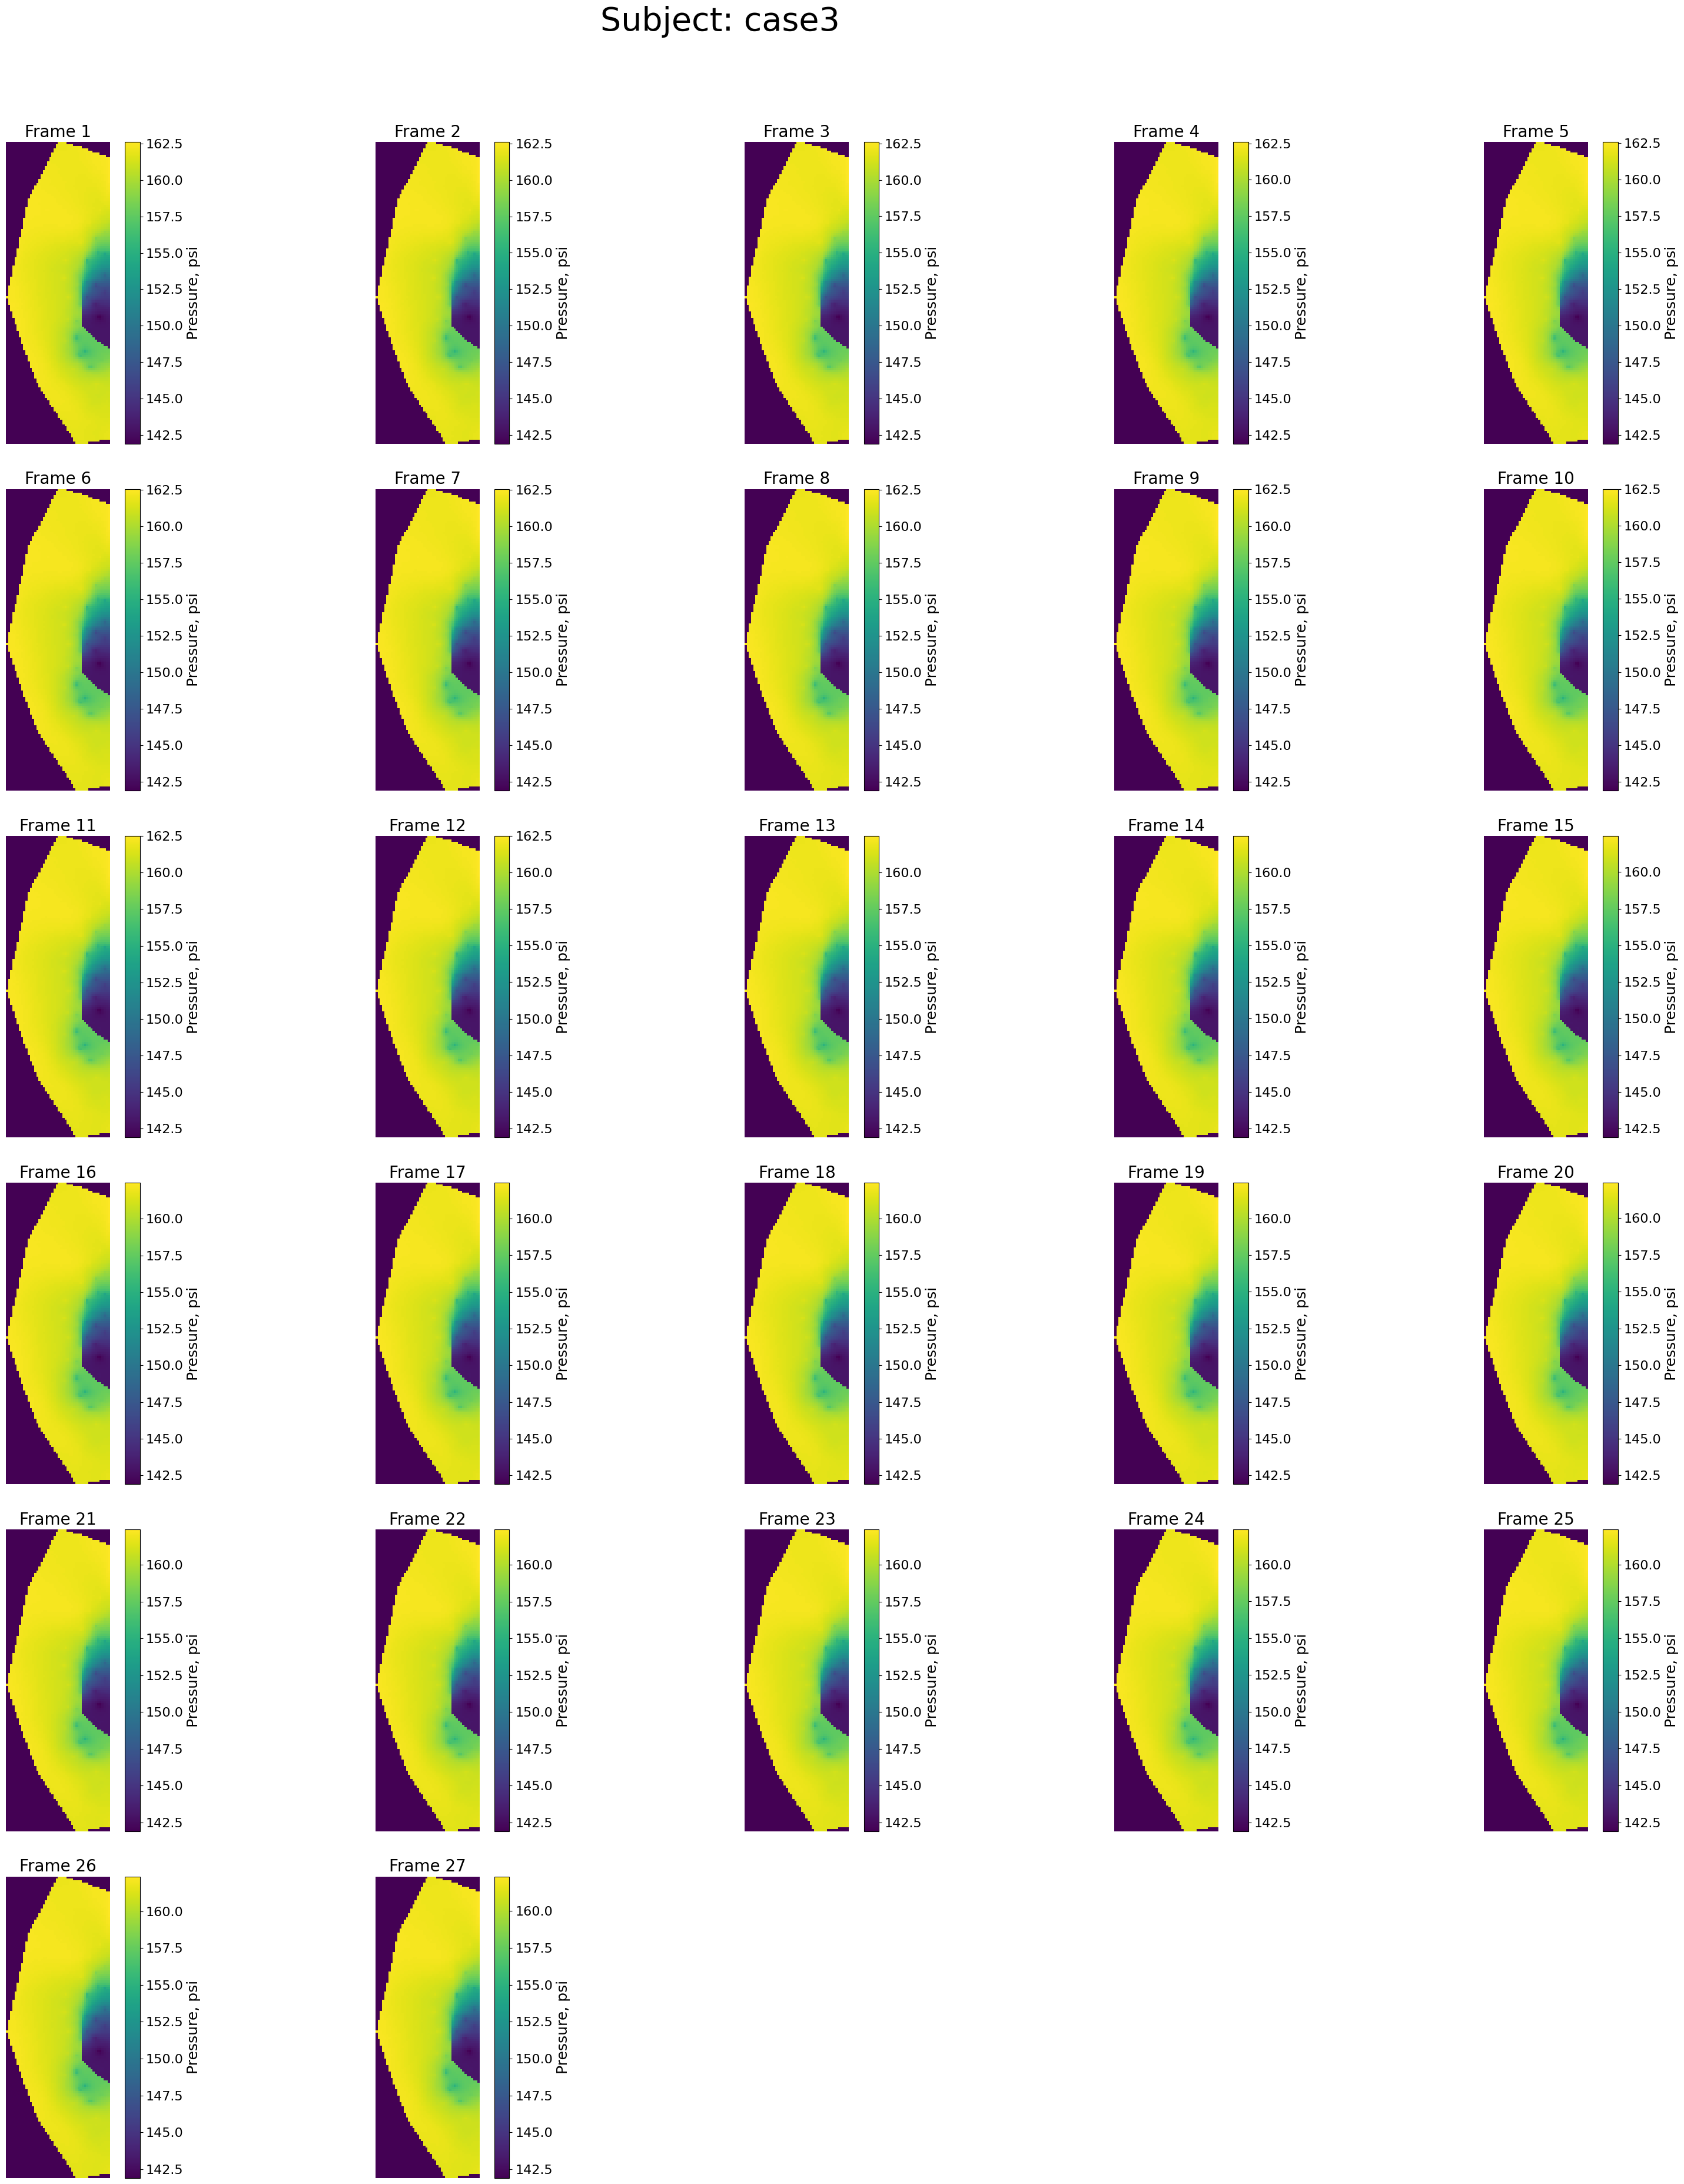

In [ ]:
tensor = test_data[subject_name]
visualize_tensor(tensor, subject_name, cmap="viridis", show_colorbar=True, save_path=None)  

# Pipline

## HOSVD Algorithm

[40, 40, 2, 40]

In [16]:
tensor = train_tensors

In [17]:
tbmd_decomposer = TuckerDecomposer(
    tensors=train_tensors,
    ranks=[48, 48, 2, 48],
    epsilon=1e-2,
    device='mps',   # 'cpu' or 'cuda' or 'mps'
    random_state=SEED   
)


# Perform decomposition
tbmd_decomposer.decompose()

cores = tbmd_decomposer.cores
factors = tbmd_decomposer.factors

INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerCore initialized with epsilon: 0.01
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerInterface initialized in collection mode
/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/venv/lib/python3.13/site-packages/tensorly/backend/__init__.py:202: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  return getattr(
INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully


In [18]:
tbmd_decomposer.reconstruct()

errors = tbmd_decomposer.reconstruction_errors
for key, error in errors.items():
    print(f"  {key}: error {error:.6f}")

INFO:TBMD.modules.TensorHOSVD:Reconstruction completed successfully


  case1: error 0.000809
  case2: error 0.000881
  case3: error 0.000824
  case4: error 0.000747
  case5: error 0.000815
  case6: error 0.000824
  case7: error 0.000665
  case8: error 0.001001
  case9: error 0.000984
  case10: error 0.000767


## Create Modal Tensor 𝐴

In [19]:
madal_processor_config = ModalProcessorConfig(
    device='mps',
    processing_strategy=ProcessingStrategy.BATCH,
    enable_progress_logging=True,
    return_numpy = False
)

batch_processor = BatchModalProcessor(madal_processor_config)
stacker = ModalTensorStacker(madal_processor_config)

modal_tensors = batch_processor.process_multiple_subjects(cores, factors)
A_tensor = stacker.stack_modal_tensors(modal_tensors)

INFO:TBMD.modules.TensorTimeInsensitiveModes:Initialized ModalTensorProcessor with device: mps
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([139, 48, 2, 48])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'case1' (1/10)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([139, 48, 2, 48])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'case2' (2/10)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([139, 48, 2, 48])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'case3' (3/10)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([139, 48, 2, 48])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'case4' (4/10)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([139, 48, 2, 48])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processe

In [20]:
# # M_tensors = {"single_subject": <torch tensor on MPS>}
# M_tensors = process_all_subjects(cores=cores, factors=factors, device='mps', return_numpy=False)

# A_tensor = stack_all_modes(M_tensors, device='mps', return_numpy=False)
# print(f"Final stacked shape: {A_tensor.shape}")

## QR Factorization

Performing QR factorization...
QR Factorization completed:
  Requested sensors: 200
  Actual rank: 200
  Success rate: 100.0%
  Early stops: 0
Factorization valid: False
Reconstruction error: 3.84e-07
Orthogonality deviation: 1.44e-01
Sensors placed: 200/200


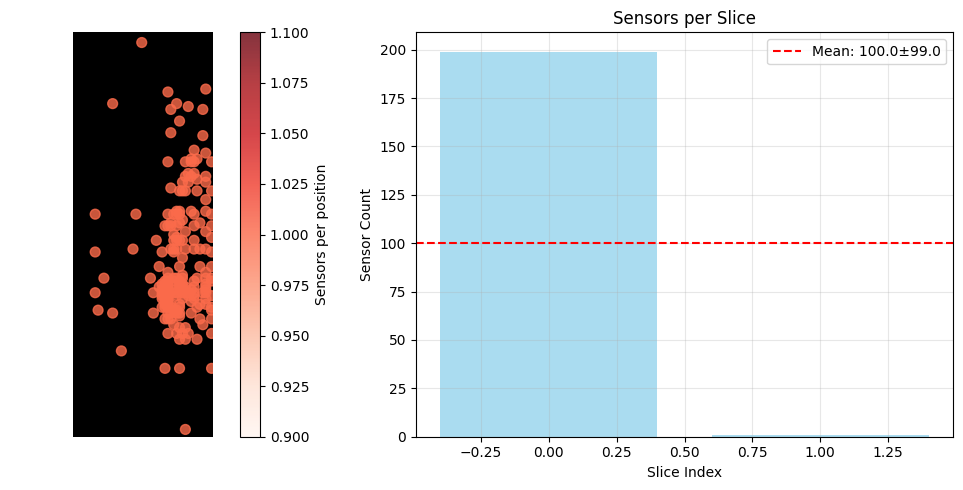

In [65]:
number_sensors = 200

qr_decomposer = TensorTubeQRDecomposition(
        tensor=A_tensor,
        N=number_sensors,
        random_state=SEED,
        check_orthogonality=True,
        uniform_distribution=False
    )

print("Performing QR factorization...")
P, Q, R = qr_decomposer.factorize()

# Validate results
is_valid, error, metrics = qr_decomposer.check_factorization()
print(f"Factorization valid: {is_valid}")
print(f"Reconstruction error: {error:.2e}")
print(f"Orthogonality deviation: {metrics['orthogonality_deviation']:.2e}")
print(f"Sensors placed: {metrics['sensor_count']}/{qr_decomposer.N}")

qr_decomposer.visualize_sensor_placement()

In [22]:
# import numpy as np
# import torch
# import tensorly as tl
# import matplotlib.pyplot as plt
# from typing import Union, Optional, Tuple

# from TBMD.utils.utils import to_torch_tensor, get_torch_device


# class TensorTubeQRDecomposition:
#     """
#     Tensor-based QR factorisation with "tube pivoting" for an N-dimensional input
#     whose last axis (length k) represents the temporal / spectral / tube dimension.
#     Supports optional uniform sensor distribution across space and slices.
#     """

#     def __init__(
#         self,
#         tensor: Union[np.ndarray, torch.Tensor, tl.tensor],
#         N: int,
#         rejection_domain: Optional[Union[np.ndarray, torch.Tensor]] = None,
#         random_state: Optional[int] = None,
#         check_orthogonality: bool = False,
#         device: str = "cpu",
#         dtype: torch.dtype = torch.float32,
#         uniform_distribution: bool = False,
#     ) -> None:
#         """Create the decomposition object and pre-compute static helpers.

#         Parameters
#         ----------
#         tensor : (..., k) array-like
#             Data cube to be factorised.
#         N : int
#             Number of sensors (pivot tubes) to select.
#         rejection_domain : bool array, optional
#             Mask of positions that cannot host a sensor.
#         random_state : int, optional
#             Seed for repeatability.
#         check_orthogonality : bool, default False
#             If True verify Q remains orthonormal after each step (slow).
#         device : {"cpu", "cuda", "mps"}
#             PyTorch device.
#         dtype : torch.dtype, default torch.float32
#         uniform_distribution : bool, default False
#             Enforce a quasi-uniform spread of sensors in space / slices.
#         """
#         # ------------------------------------------------------------------
#         # 0. Reproducibility -------------------------------------------------
#         if random_state is not None:
#             np.random.seed(random_state)
#             tl.check_random_state(random_state)
#             torch.manual_seed(random_state)

#         # ------------------------------------------------------------------
#         # 1. Basic attributes ----------------------------------------------
#         self.device = get_torch_device(device)
#         self.dtype = dtype
#         self.uniform_distribution = uniform_distribution

#         self.tensor = to_torch_tensor(tensor, device=self.device, dtype=self.dtype)
#         if self.tensor.ndim < 3:
#             raise ValueError("Input tensor must have at least 3 dimensions (…, k).")

#         self.spatial_shape: Tuple[int, ...] = self.tensor.shape[:-1]
#         self.k: int = self.tensor.shape[-1]
#         if not (1 <= N <= self.k):
#             raise ValueError(f"N must be in [1, {self.k}]. Got N={N}.")
#         self.N: int = N

#         # ------------------------------------------------------------------
#         # 2. Rejection / availability map ----------------------------------
#         if rejection_domain is None:
#             self.available = torch.ones(self.spatial_shape, dtype=torch.bool, device=self.device)
#         else:
#             rej_dom = to_torch_tensor(rejection_domain, dtype=torch.bool, device=self.device)
#             if rej_dom.shape != self.spatial_shape:
#                 raise ValueError(
#                     "rejection_domain shape must match spatial part "
#                     f"{self.spatial_shape}, got {rej_dom.shape}."
#                 )
#             self.available = rej_dom.clone()

#         # ------------------------------------------------------------------
#         # 3. Containers for the result -------------------------------------
#         self.check_orthogonality = check_orthogonality
#         self.P: Optional[torch.Tensor] = None  # sensor indicator
#         self.Q: Optional[torch.Tensor] = None  # k×k orthogonal
#         self.R: Optional[torch.Tensor] = None  # same shape as tensor

#         # ------------------------------------------------------------------
#         # 4. Uniform-distribution helpers ----------------------------------
#         # counts of sensors per slice of every spatial dimension
#         self.dimension_counts = {dim: {} for dim in range(len(self.spatial_shape))}
#         # counts per z-slice (3-D tensors) for inter-slice balance
#         self.slice_counts: dict[int, int] = {}
#         # target number (float) per slice – set later inside _identify_...
#         self.target_sensors_per_slice: float = 0.0

#         # Similar-region dictionary for 3-D+ tensors
#         self.similar_regions = {}
#         if self.uniform_distribution and len(self.spatial_shape) >= 3:
#             self._identify_similar_regions()

#     # ----------------------------------------------------------------------
#     # Helper: similar-region discovery (3-D+) -------------------------------
#     def _identify_similar_regions(self):
#         """Group (x, y) locations that show similar behaviour along z."""
#         if len(self.spatial_shape) < 3:
#             return

#         # Build a simple descriptor: value of the first tube entry
#         rep = self.tensor[..., 0].detach().cpu().numpy()
#         for x in range(self.spatial_shape[0]):
#             for y in range(self.spatial_shape[1]):
#                 pattern = tuple(np.round(rep[x, y, :], decimals=3))
#                 self.similar_regions.setdefault(pattern, []).append((x, y))

#         # Initialise slice histogram and per-slice target
#         for z in range(self.spatial_shape[2]):
#             self.slice_counts[z] = 0
#         self.target_sensors_per_slice = self.N / self.spatial_shape[2]

#     # ----------------------------------------------------------------------
#     # Householder helper ----------------------------------------------------
#     def _compute_householder_vector(self, v: torch.Tensor) -> torch.Tensor:
#         sigma = torch.norm(v)
#         if sigma < 1e-12:
#             return torch.zeros_like(v)
#         sign_v1 = torch.sign(v[0]) if v[0] != 0 else torch.tensor(1.0, device=self.device, dtype=self.dtype)
#         u = v.clone()
#         u[0] += sign_v1 * sigma
#         denom = torch.sqrt(2 * sigma * (sigma + torch.abs(v[0])))
#         return u / denom

#     # ----------------------------------------------------------------------
#     # Pivot selection -------------------------------------------------------
#     def _get_pivot_position(self, R: torch.Tensor, d: int) -> Tuple[int, ...]:
#         norms = torch.sum(torch.abs(R[..., d:]), dim=-1)
#         norms = torch.where(self.available, norms, torch.tensor(float('-inf'), device=self.device, dtype=self.dtype))

#         if self.uniform_distribution and len(self.spatial_shape) > 2:
#             norms -= self._calculate_distribution_penalty(norms)
#             norms -= self._calculate_slice_penalty(norms)

#         flat_idx = torch.argmax(norms).item()
#         pivot_idx = np.unravel_index(flat_idx, self.spatial_shape)

#         # Mark similar regions unavailable for future picks
#         if self.uniform_distribution and len(self.spatial_shape) >= 3 and self.similar_regions:
#             self._mark_similar_positions_unavailable(pivot_idx)
#         # Update slice histogram
#         if len(self.spatial_shape) >= 3:
#             z = pivot_idx[2]
#             self.slice_counts[z] = self.slice_counts.get(z, 0) + 1
#         return pivot_idx

#     def _calculate_slice_penalty(self, norms: torch.Tensor) -> torch.Tensor:
#         if len(self.spatial_shape) < 3 or sum(self.slice_counts.values()) == 0:
#             return torch.zeros_like(norms)
#         penalty = torch.zeros_like(norms)
#         total = sum(self.slice_counts.values())
#         for z in range(self.spatial_shape[2]):
#             current = self.slice_counts.get(z, 0)
#             imbalance = current - total / self.spatial_shape[2]
#             if imbalance > 0:
#                 slices = [slice(None), slice(None), z]
#                 slices.extend([slice(None)] * (len(self.spatial_shape) - 3))
#                 penalty[tuple(slices)] += imbalance * 0.8 * torch.max(norms)
#         return penalty

#     def _mark_similar_positions_unavailable(self, pivot: Tuple[int, ...]):
#         if len(self.spatial_shape) < 3:
#             return
#         x, y = pivot[0], pivot[1]
#         for positions in self.similar_regions.values():
#             if (x, y) in positions:
#                 for px, py in positions:
#                     if (px, py) != (x, y):
#                         for z in range(self.spatial_shape[2]):
#                             self.available[px, py, z] = False
#                 break

#     def _calculate_distribution_penalty(self, norms: torch.Tensor) -> torch.Tensor:
#         if self.P is None:
#             return torch.zeros_like(norms)
#         penalty = torch.zeros_like(norms)
#         total_sensors = torch.sum(self.P).item()
#         if total_sensors == 0:
#             return penalty
#         for dim in range(len(self.spatial_shape)):
#             for i in range(self.spatial_shape[dim]):
#                 slices = [slice(None)] * len(self.spatial_shape)
#                 slices[dim] = i
#                 density = torch.sum(self.P[tuple(slices)]).item() / total_sensors
#                 penalty[tuple(slices)] += density * 0.5 * torch.max(norms)
#         return penalty

#     def _update_dimension_counts(self, pivot: Tuple[int, ...]):
#         for dim, idx in enumerate(pivot):
#             self.dimension_counts[dim][idx] = self.dimension_counts[dim].get(idx, 0) + 1

#     # ----------------------------------------------------------------------
#     # Public API ------------------------------------------------------------
#     def factorize(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
#         """Run the pivoted QR across tubes."""
#         self.R = self.tensor.clone()
#         self.Q = torch.eye(self.k, device=self.device, dtype=self.dtype)
#         self.P = torch.zeros(self.spatial_shape, device=self.device, dtype=torch.int32)
#         # reset distribution statistics
#         self.dimension_counts = {dim: {} for dim in range(len(self.spatial_shape))}
#         if len(self.spatial_shape) >= 3:
#             for z in range(self.spatial_shape[2]):
#                 self.slice_counts[z] = 0

#         for d in range(min(self.N, self.k)):
#             pivot = self._get_pivot_position(self.R, d)
#             tube = self.R[pivot + (slice(d, None),)]
#             if torch.sum(torch.abs(tube)) < 1e-12:
#                 break
#             self.P[pivot] = 1
#             self.available[pivot] = False
#             if self.uniform_distribution:
#                 self._update_dimension_counts(pivot)

#             u = self._compute_householder_vector(tube)
#             if torch.norm(u) < 1e-12:
#                 continue
#             sub_R = self.R[..., d:].reshape(-1, self.k - d)
#             sub_R -= 2 * (sub_R @ u).unsqueeze(1) * u
#             Q_block = self.Q[:, d:]
#             Q_block -= 2 * (Q_block @ u.unsqueeze(-1)) * u.unsqueeze(0)

#             if self.check_orthogonality and not torch.allclose(self.Q.T @ self.Q, torch.eye(self.k, device=self.device, dtype=self.dtype), atol=1e-5):
#                 print(f"Warning: Q lost orthogonality at step {d}")
#         return self.P, self.Q, self.R

#     def check_factorization(self, tol: float = 1e-6) -> Tuple[bool, float]:
#         if any(x is None for x in (self.P, self.Q, self.R)):
#             raise ValueError("Run factorize() first.")
#         ortho = torch.allclose(self.Q.T @ self.Q, torch.eye(self.k, device=self.device, dtype=self.dtype), atol=tol)
#         RQ_T = torch.tensordot(self.R, self.Q.T, dims=([-1], [0]))
#         rel_err = torch.norm(self.tensor - RQ_T) / torch.norm(self.tensor)
#         return bool(ortho), float(rel_err.item())

#     # ----------------------------------------------------------------------
#     # Visualisation ---------------------------------------------------------
#     def visualize_sensor_placement(self) -> None:
#         """Show where sensors (P==1) are placed."""
#         if self.P is None:
#             raise ValueError("Run factorize() first.")
#         p = self.P.detach().cpu().numpy()
#         if p.ndim == 2:
#             sensor_map = p
#         else:
#             sensor_map = np.max(p, axis=tuple(range(2, p.ndim)))
#         fig, ax = plt.subplots(figsize=(sensor_map.shape[1] / 10, sensor_map.shape[0] / 10))
#         ax.set_facecolor("black")
#         ax.imshow(np.zeros(sensor_map.shape), cmap="gray", origin="upper")
#         pos = np.argwhere(sensor_map == 1)
#         if pos.size > 0:
#             ax.scatter(pos[:, 1], pos[:, 0], s=20, c="red")
#         ax.set_title(f"Tube-Pivot QR: sensors (N={self.N})", color="white")
#         ax.axis("off")
#         plt.show()
#         # Per-slice histogram for 3-D tensors
#         if len(self.spatial_shape) >= 3:
#             counts = [np.sum(p[..., z]) for z in range(self.spatial_shape[2])]
#             plt.figure(figsize=(10, 4))
#             plt.bar(range(self.spatial_shape[2]), counts)
#             plt.title("Sensors per slice")
#             plt.xlabel("slice z")
#             plt.ylabel("count")
#             plt.show()

# number_sensors = 200

# qr_decomp = TensorTubeQRDecomposition(
#     tensor=A_tensor,
#     N=number_sensors,
#     rejection_domain=None,
#     check_orthogonality=False,
#     uniform_distribution=True,
#     device='mps',   # 'cpu' or 'cuda' or 'mps'
#     random_state=SEED

# )
# P, v, R = qr_decomp.factorize()

# is_ortho, rel_err = qr_decomp.check_factorization()
# print(f"Q orthonormal? {is_ortho}\nrelative error = {rel_err:.5e}")

# qr_decomp.visualize_sensor_placement()

Wells matrix shape: torch.Size([139, 48])
Number of wells: 30.0


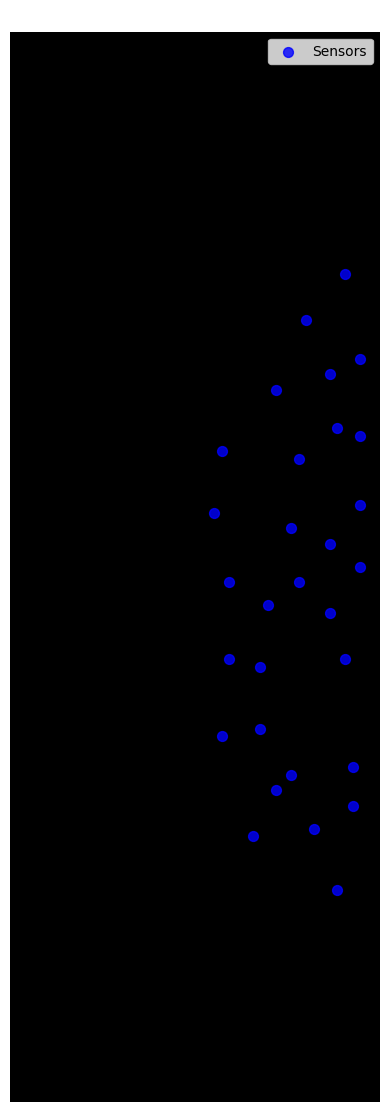

New P shape: torch.Size([139, 48, 2])


In [83]:
# Build wells matrix using the method
wells_matrix = build_wells_matrix(wells, A_tensor.shape, device='mps')

print(f"Wells matrix shape: {wells_matrix[subject_name].shape}")
print(f"Number of wells: {torch.sum(wells_matrix[subject_name]).item()}")

# Visualize wells placement
visualize_wells_placement(wells_matrix[subject_name])

P = wells_matrix[subject_name]

if P.ndim == 2:
    P = P.unsqueeze(-1).repeat(1, 1, 2)
print("New P shape:", P.shape)

## Sparse measurements matrix Y

In [84]:
Y_mats = build_Y_matrices(test_tensors, P, device="cpu")

slice_number = 10
Y = Y_mats[subject_name][..., slice_number]
X = to_torch_tensor(test_tensors[subject_name][..., slice_number], device="cpu")

print("Y shape:", Y.shape)
print("X shape:", X.shape)

Y shape: torch.Size([139, 48, 2])
X shape: torch.Size([139, 48, 2])


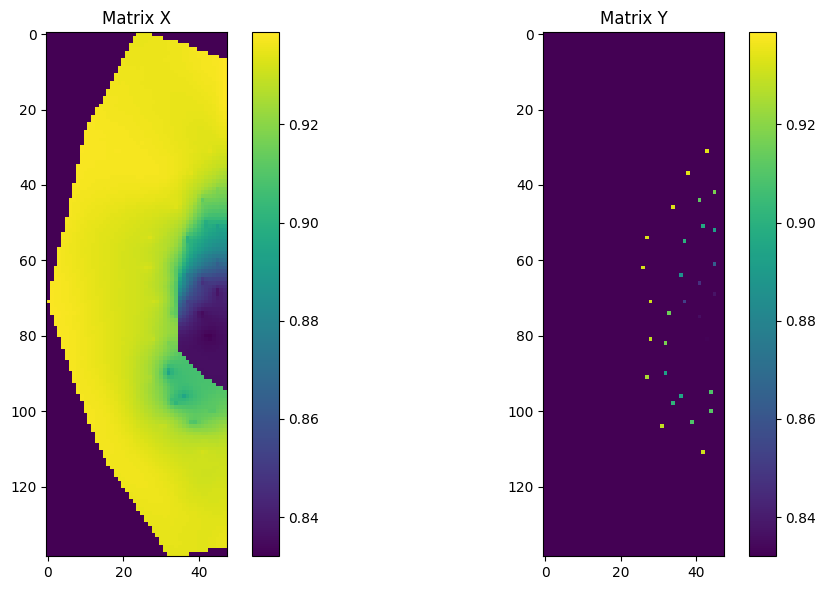

In [85]:
plot_two_matrices(X[:,:,0], Y[:,:,0])

# plot_two_matrices(X, Y, cmap="viridis")

In [86]:
# plot_two_matrices(X[:,:,1], Y[:,:,1])

## Tensor-based Compressive Sensing Algorithm

In [87]:
compressive_sensing_config = CompressiveSensingConfig(    
    max_iter = 1000,
    tol = 1e-4,                 # stop criterion on max(primal, dual)
    epsilon_l1 = 1e-2,          # ε in (28)
    delta_init = 1.0,           # δ₀
    delta_max = 1.0,            # δ_max (36)
    relax_lambda = 0.95,        # mixing x and d
    device = "cpu",
    dtype = torch.float32
)

extension_compressive_sensing_config = ExtensionCompressiveSensingConfig(
    solver = "cholesky",         # cholesky | direct | svd
    reg = 1e-8,                  # diagonal regularization
    delta_policy = "boyd",       # boyd | cap_only
    stop_policy = "residual",    # residual | relative | both
    relative_window = 5,         # window for relative criterion
    relative_drop = 1e-3,        # required relative drop
    collect_history = True,
)

solver = TensorCompressiveSensing(A_tensor, P, Y, compressive_sensing_config, extension_compressive_sensing_config)
x_hat, met = solver.solve()

print("converged:", met.converged, "iters:", met.iterations, "obj:", met.objective)
print("rel_error:", solver.reconstruction_error(x_hat))

converged: True iters: 69 obj: 0.0010000598203623668
rel_error: 0.001621002098545432


In [88]:
# compressive_sensing_config = CompressiveSensingConfig(
#     max_iter=1000,
#     epsilon_l1=1e-2,
#     relaxation_lambda=0.95,
#     delta_init=1.0,
#     delta_max=1.0,
#     convergence_tol=1e-7,
#     solver_method="triangular",
#     device="cpu"
# )

# solver = TensorCompressiveSensing(A_tensor, P, Y, compressive_sensing_config)
# x_hat, metrics = solver.solve_with_metrics()

# Reconstruct the field matrix X

In [89]:
X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)

Reconstructed tensor shape: torch.Size([139, 48, 2]), mode used: 3


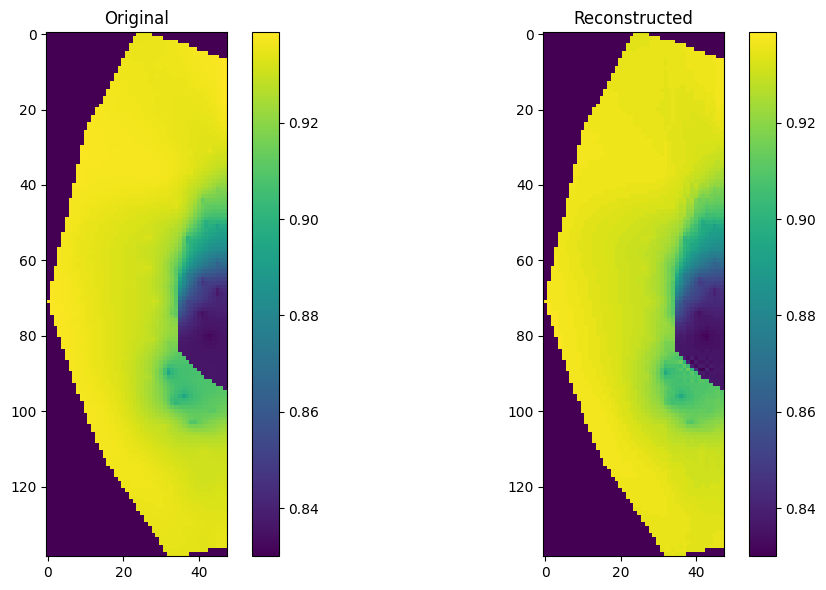

In [90]:
plot_two_matrices(X[:,:,0], X_reconstructed[:,:,0], titles=("Original", "Reconstructed"))

# plot_two_matrices(X, X_reconstructed, titles=("Original", "Reconstructed"))

In [91]:
# plot_two_matrices(X[:,:,1], X_reconstructed[:,:,1], titles=("Original", "Reconstructed"))

In [92]:
original_X = inverse_normalization(
    X, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)
original_X_reconstructed = inverse_normalization(
    X_reconstructed, 
    normalization_method=normalization_method, 
    global_params=minmax_params, 
    background_value=BG
)

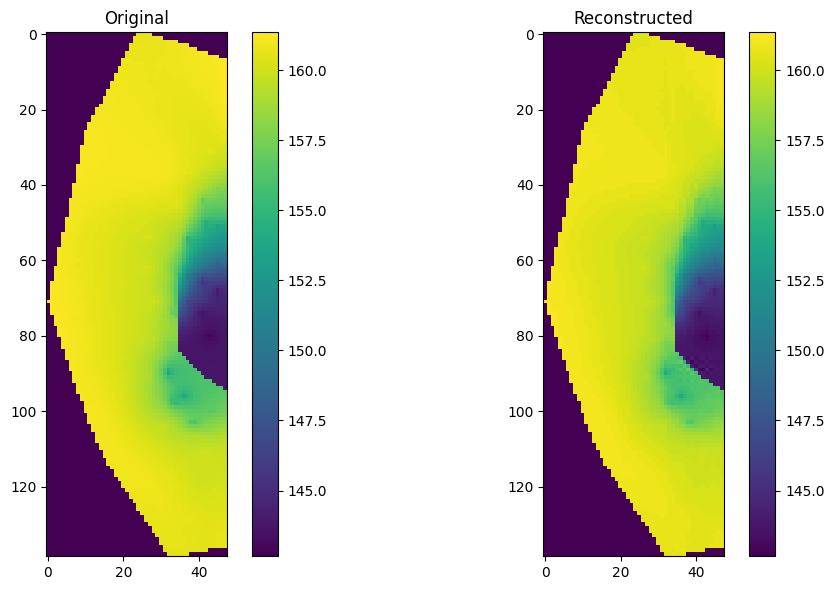

In [93]:
plot_two_matrices(original_X[:,:,0], original_X_reconstructed[:,:,0], titles=("Original", "Reconstructed"))

# plot_two_matrices(original_X, original_X_reconstructed, titles=("Original", "Reconstructed"))

In [94]:
error, mse, ssim_value, psnr_value = compute_metrics(original_X, original_X_reconstructed, background_value=BG)

print(f"Reconstruction Error (error): {error:.5f}")
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Structural Similarity Index (SSIM): {ssim_value:.5f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_value:.5f}")

Reconstruction Error (error): 0.00110
Mean Squared Error (MSE): 0.01123
Structural Similarity Index (SSIM): 0.95721
Peak Signal-to-Noise Ratio (PSNR): 63.65368


In [95]:
# def plot_original_reconstructed_diff(
#     original,
#     reconstructed,
#     *,
#     common_cmap: str = "viridis",
#     diff_cmap: str = "RdBu_r",
#     figsize: tuple = (20, 6),
#     wspace: float = 0.01,
#     hspace: float = 0.01,
#     colorbar_labels: tuple | None = ("Pressure, psi", "Pressure, psi", "Pressure difference, psi"),
#     show_colorbar: bool = True,
#     colorbar_fontsize: int = 12,
# ):
#     import numpy as np
#     import torch
#     import matplotlib.pyplot as plt
#     from mpl_toolkits.axes_grid1 import make_axes_locatable

#     def _to_numpy(x):
#         if torch.is_tensor(x):
#             return x.detach().cpu().numpy()
#         elif isinstance(x, np.ndarray):
#             return x
#         else:
#             raise TypeError("Input must be a NumPy array or a torch.Tensor.")

#     orig_np = _to_numpy(original)
#     rec_np = _to_numpy(reconstructed)

#     if orig_np.shape != rec_np.shape:
#         raise ValueError(
#             f"Original and reconstructed shapes differ: {orig_np.shape} vs {rec_np.shape}."
#         )

#     diff_np = orig_np - rec_np

#     # Вычисление общих пределов для цветовой шкалы
#     vmin_common = max(0, min(np.min(orig_np[orig_np > 0]), np.min(rec_np[rec_np > 0])))
#     vmax_common = max(np.max(orig_np), np.max(rec_np))

#     # Создание фигуры и осей
#     fig, axes = plt.subplots(1, 3, figsize=figsize)
#     fig.subplots_adjust(wspace=wspace, hspace=hspace)

#     # Отображение изображений
#     im0 = axes[0].imshow(orig_np, cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
#     im1 = axes[1].imshow(rec_np, cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
#     im2 = axes[2].imshow(diff_np, cmap=diff_cmap)

#     # Убираем оси у всех subplots
#     for ax in axes:
#         ax.axis('off')

#     # Добавление colorbar с соответствием высоте изображения
#     if show_colorbar:
#         for ax, im, label in zip(axes, [im0, im1, im2], colorbar_labels):
#             divider = make_axes_locatable(ax)
#             cax = divider.append_axes("right", size="10%", pad=0.1)
#             cbar = plt.colorbar(im, cax=cax)
#             cbar.set_label(label, fontsize=colorbar_fontsize)
#             cbar.ax.tick_params(labelsize=colorbar_fontsize-2)

#     plt.show()
    
def plot_original_reconstructed_diff(
    original,
    reconstructed,
    *,
    common_cmap: str = "viridis",
    diff_cmap: str = "RdBu_r",
    figsize: tuple = (20, 6),
    wspace: float = 0.01,
    hspace: float = 0.01,
    colorbar_labels: tuple | None = ("Pressure, psi", "Pressure, psi", "Pressure difference, psi"),
    show_colorbar: bool = True,
    colorbar_fontsize: int = 12,
):
    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # ---------- helpers ----------
    def _to_numpy(x):
        if torch.is_tensor(x):
            return x.detach().cpu().numpy()
        elif isinstance(x, np.ndarray):
            return x
        else:
            raise TypeError("Input must be a NumPy array or a torch.Tensor.")

    def _safe_pos_min(a: np.ndarray):
        pos = a[a > 0]
        return pos.min() if pos.size > 0 else None

    def _ensure_labels(lbls):
        if lbls is None:
            return ("", "", "")
        if len(lbls) != 3:
            raise ValueError("colorbar_labels must be a tuple of three strings.")
        return lbls

    # ---------- data prep ----------
    orig_np = _to_numpy(original)
    rec_np  = _to_numpy(reconstructed)

    if orig_np.shape != rec_np.shape:
        raise ValueError(
            f"Original and reconstructed shapes differ: {orig_np.shape} vs {rec_np.shape}."
        )

    diff_np = orig_np - rec_np

    # ---------- common vmin/vmax for original & reconstructed ----------
    # Если есть положительные значения в обеих матрицах — берём минимальный положительный.
    # Иначе используем реальный минимум (допускает отрицательные значения).
    pos_min_orig = _safe_pos_min(orig_np)
    pos_min_rec  = _safe_pos_min(rec_np)
    if (pos_min_orig is not None) and (pos_min_rec is not None):
        vmin_common = float(min(pos_min_orig, pos_min_rec))
    else:
        vmin_common = float(min(orig_np.min(), rec_np.min()))
    vmax_common = float(max(orig_np.max(), rec_np.max()))
    if not (vmax_common > vmin_common):
        vmax_common = 1.0 if vmin_common == 0 else vmin_common * 1.1

    # ---------- symmetric limits for difference (centered at 0) ----------
    d = float(max(abs(diff_np.min()), abs(diff_np.max())))
    vmin_diff, vmax_diff = -d, d
    if d == 0:
        vmin_diff, vmax_diff = -1.0, 1.0  # на случай полностью нулевой разницы

    labels = _ensure_labels(colorbar_labels)

    # # ---------- combined figure with 3 panels ----------
    # fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=False)
    # fig.subplots_adjust(wspace=wspace, hspace=hspace)

    # im0 = axes[0].imshow(orig_np, cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
    # im1 = axes[1].imshow(rec_np,  cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
    # im2 = axes[2].imshow(diff_np,  cmap=diff_cmap,   vmin=vmin_diff,  vmax=vmax_diff)

    # for ax in axes:
    #     ax.axis('off')
    #     ax.set_aspect('equal')  # сохраняем пропорции

    # if show_colorbar:
    #     for ax, im, label in zip(axes, (im0, im1, im2), labels):
    #         divider = make_axes_locatable(ax)
    #         # аккуратные боковые шкалы; при желании можно уменьшить size/pad
    #         cax = divider.append_axes("right", size="10%", pad=0.1)
    #         cbar = plt.colorbar(im, cax=cax)
    #         if label:
    #             cbar.set_label(label, fontsize=colorbar_fontsize)
    #         cbar.ax.tick_params(labelsize=colorbar_fontsize - 2)

    # plt.show()

    # ---------- individual figures (each panel separately) ----------
    # 1) Original
    fig_o, ax_o = plt.subplots(figsize=(figsize[0] / 3, figsize[1]))  # разумный размер
    im_o = ax_o.imshow(orig_np, cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
    ax_o.axis('off')
    ax_o.set_aspect('equal')
    if show_colorbar:
        divider_o = make_axes_locatable(ax_o)
        cax_o = divider_o.append_axes("right", size="10%", pad=0.1)
        cbar_o = plt.colorbar(im_o, cax=cax_o)
        if labels[0]:
            cbar_o.set_label(labels[0], fontsize=colorbar_fontsize)
        cbar_o.ax.tick_params(labelsize=colorbar_fontsize - 2)
    plt.show()

    # 2) Reconstructed
    fig_r, ax_r = plt.subplots(figsize=(figsize[0] / 3, figsize[1]))
    im_r = ax_r.imshow(rec_np, cmap=common_cmap, vmin=vmin_common, vmax=vmax_common)
    ax_r.axis('off')
    ax_r.set_aspect('equal')
    if show_colorbar:
        divider_r = make_axes_locatable(ax_r)
        cax_r = divider_r.append_axes("right", size="10%", pad=0.1)
        cbar_r = plt.colorbar(im_r, cax=cax_r)
        if labels[1]:
            cbar_r.set_label(labels[1], fontsize=colorbar_fontsize)
        cbar_r.ax.tick_params(labelsize=colorbar_fontsize - 2)
    plt.show()

    # 3) Difference
    fig_d, ax_d = plt.subplots(figsize=(figsize[0] / 3, figsize[1]))
    im_d = ax_d.imshow(diff_np, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    ax_d.axis('off')
    ax_d.set_aspect('equal')
    if show_colorbar:
        divider_d = make_axes_locatable(ax_d)
        cax_d = divider_d.append_axes("right", size="10%", pad=0.1)
        cbar_d = plt.colorbar(im_d, cax=cax_d)
        if labels[2]:
            cbar_d.set_label(labels[2], fontsize=colorbar_fontsize)
        cbar_d.ax.tick_params(labelsize=colorbar_fontsize - 2)
    plt.show()


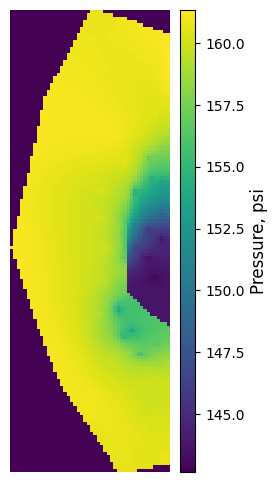

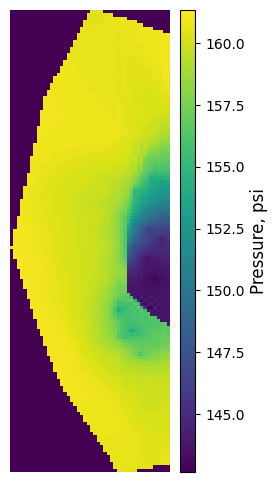

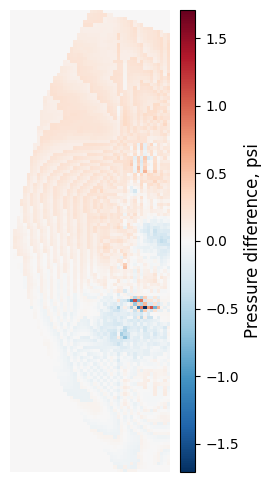

In [96]:
plot_original_reconstructed_diff(original_X[:,:,0], original_X_reconstructed[:,:,0])

# plot_original_reconstructed_diff(
#     original=original_X,
#     reconstructed=original_X_reconstructed,
#     figsize=(20, 6),
#     wspace=0.01, hspace=0.01,
#     colorbar_labels=("Pressure, psi", "Pressure, psi", "Pressure difference, psi"),
#     show_colorbar=True,
#     colorbar_fontsize=12,
# )


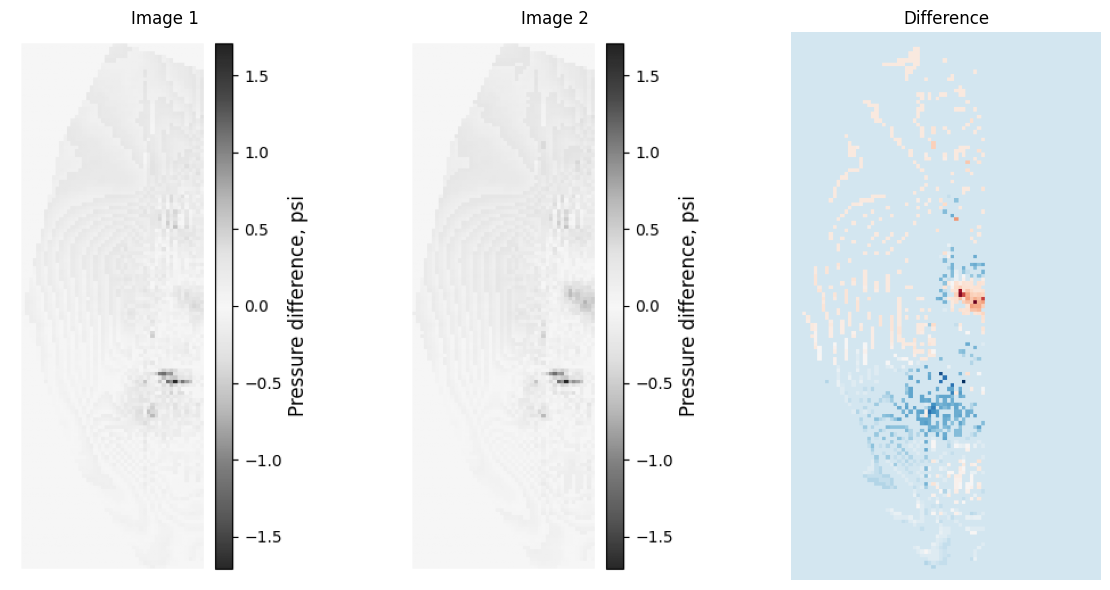

In [63]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

def compare_images(path1, path2, cmap="gray", figsize=(12, 6), show_diff=True):
    """
    Сравнивает два изображения по указанным путям.
    Показывает оба изображения и их разницу (поэлементно).

    Parameters
    ----------
    path1 : str
        Путь к первому изображению.
    path2 : str
        Путь ко второму изображению.
    cmap : str
        Цветовая карта для отображения (по умолчанию "gray").
    figsize : tuple
        Размер фигуры для отображения.
    show_diff : bool
        Показывать ли разницу между изображениями.
    """
    img1 = np.array(Image.open(path1).convert("L"))
    img2 = np.array(Image.open(path2).convert("L"))

    fig, axes = plt.subplots(1, 3 if show_diff else 2, figsize=figsize)
    axes[0].imshow(img1, cmap=cmap)
    axes[0].set_title("Image 1")
    axes[0].axis("off")

    axes[1].imshow(img2, cmap=cmap)
    axes[1].set_title("Image 2")
    axes[1].axis("off")

    if show_diff:
        diff = img1.astype(np.float32) - img2.astype(np.float32)
        axes[2].imshow(diff, cmap="RdBu_r")
        axes[2].set_title("Difference")
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()

compare_images("/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/algorithm/images/difference_field_wells_pressure_4d.png", "/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/algorithm/images/difference_field_pressure_4d.png")

In [58]:
original_X.shape

torch.Size([139, 48, 2])

In [97]:
# save_pressure_for_tnavigator.py
# Python 3.10+
from __future__ import annotations
import os
import numpy as np

try:
    import torch
except ImportError:
    torch = None  # позволит работать только с numpy

def _to_numpy_2d(x, expect_shape=(139, 48)) -> np.ndarray:
    """Приводит вход к numpy.float64 2D и валидирует форму."""
    if torch is not None and isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError(f"Ожидалась 2D матрица, получено {x.shape}.")
    if expect_shape and tuple(x.shape) != tuple(expect_shape):
        raise ValueError(f"Ожидался размер {expect_shape}, получено {x.shape}.")
    return x

def _maybe_transpose(arr: np.ndarray, ij_order: str) -> np.ndarray:
    """
    Управляет соответствием осей:
    - 'JI' (по умолчанию): arr.shape == (J, I) -> J=строка 1..NY, I=столбец 1..NX
    - 'IJ': arr.shape == (I, J), тогда транспонируем для выгрузки
    """
    ij_order = ij_order.upper()
    if ij_order not in ("JI", "IJ"):
        raise ValueError("ij_order должен быть 'JI' или 'IJ'.")
    return arr.T if ij_order == "IJ" else arr

def _write_ijk_csv(arr: np.ndarray, path: str, value_header: str = "Pressure, psi") -> None:
    """
    Пишет CSV вида: I,J,K,Value
    I=1..NX, J=1..NY, K=1 (один слой), Value=значение в psi.
    """
    ny, nx = arr.shape  # строки=J, столбцы=I
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w", encoding="utf-8", newline="") as f:
        f.write("I,J,K,Value\n")
        for j in range(ny):        # J: 1..NY
            for i in range(nx):    # I: 1..NX
                val = arr[j, i]
                f.write(f"{i+1},{j+1},1,{val:.6f}\n")

def save_pressure_for_tnavigator(
    original_X,
    original_X_reconstructed,
    out_dir: str = "export",
    ij_order: str = "JI",
) -> dict:
    """
    Сохраняет три CSV для импорта в tNavigator:
    - pressure_original_psi.csv
    - pressure_reconstructed_psi.csv
    - pressure_difference_psi.csv   (original - reconstructed)

    Параметры:
    - ij_order: 'JI' если массивы имеют форму (NY, NX)=(139,48);
                'IJ' если (NX, NY) и требуется транспонирование.
    """
    X = _maybe_transpose(_to_numpy_2d(original_X), ij_order)
    Xrec = _maybe_transpose(_to_numpy_2d(original_X_reconstructed), ij_order)
    diff = X - Xrec  # знак важен для анализа (положит. = реконструкция занижает давление)

    paths = {
        "original": os.path.join(out_dir, "pressure_original_psi.csv"),
        "reconstructed": os.path.join(out_dir, "pressure_reconstructed_psi.csv"),
        "difference": os.path.join(out_dir, "pressure_difference_psi.csv"),
    }
    _write_ijk_csv(X, paths["original"])
    _write_ijk_csv(Xrec, paths["reconstructed"])
    _write_ijk_csv(diff, paths["difference"])
    return paths



files = save_pressure_for_tnavigator(original_X[:,:,0], original_X_reconstructed[:,:,0], out_dir="export_4d_wells", ij_order="JI")
print("Сохранено:")
for k, v in files.items():
    print(f" - {k}: {v}")


Сохранено:
 - original: export_4d_wells/pressure_original_psi.csv
 - reconstructed: export_4d_wells/pressure_reconstructed_psi.csv
 - difference: export_4d_wells/pressure_difference_psi.csv


In [1]:
import os
import pandas as pd

# Define the paths to the directories
sensors_dir = '/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/algorithm/export_4d_sensors'
wells_dir = '/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/algorithm/export_4d_wells'

# List all files in both directories
sensors_files = sorted(os.listdir(sensors_dir))
wells_files = sorted(os.listdir(wells_dir))

# Ensure both directories have the same number of files
if len(sensors_files) != len(wells_files):
    print("Mismatch in the number of files between sensors and wells directories.")
else:
    for sensor_file, well_file in zip(sensors_files, wells_files):
        sensor_path = os.path.join(sensors_dir, sensor_file)
        well_path = os.path.join(wells_dir, well_file)

        # Read the CSV files
        sensor_data = pd.read_csv(sensor_path)
        well_data = pd.read_csv(well_path)

        # Compare the dataframes
        if sensor_data.equals(well_data):
            print(f"{sensor_file} and {well_file} are identical.")
        else:
            print(f"{sensor_file} and {well_file} differ.")

pressure_difference_psi.csv and pressure_difference_psi.csv differ.
pressure_original_psi.csv and pressure_original_psi.csv are identical.
pressure_reconstructed_psi.csv and pressure_reconstructed_psi.csv differ.


# Analitycs

In [ ]:
# import torch

# def build_progressive_P(
#     wells: dict[str, list[tuple[int, int]]],
#     N: int,
#     grid_shape: tuple[int, int],
#     *,
#     device: str | torch.device = "cpu",
#     verbose: bool = True,
# ) -> torch.Tensor:
#     """
#     Формирует матрицу P размера (H, W) с первыми N уникальными координатами из словаря `wells`.
#     Координаты, выходящие за пределы сетки, пропускаются, но логируются.

#     Parameters
#     ----------
#     wells : dict[str, list[tuple[int,int]]]
#         {'subject': [(i, j), ...], ...}
#     N : int
#         Сколько сенсоров оставить.
#     grid_shape : (H, W)
#         Размер поля, к которому применяется P.
#     device : 'cpu' | 'cuda' | 'mps' | torch.device
#         Где создавать тензор.
#     verbose : bool
#         Печатать ли предупреждения о пропущенных координатах.

#     Returns
#     -------
#     P : torch.Tensor
#         2-D маска с единицами в позициях сенсоров.
#     """
#     H, W = grid_shape
#     P = torch.zeros((H, W), dtype=torch.int8, device=device)

#     # Собираем уникальные координаты с сохранением порядка
#     unique_wells = []
#     seen = set()
#     for coords in wells.values():
#         for i, j in coords:
#             if (i, j) not in seen:
#                 unique_wells.append((i, j))
#                 seen.add((i, j))

#     # Берём первые N координат
#     selected = unique_wells[:N]
#     for i, j in selected:
#         if 0 <= i < H and 0 <= j < W:
#             P[i, j] = 1
#         elif verbose:
#             print(f"[WARN] ({i}, {j}) за пределами {grid_shape} – пропущено.")

#     return P

In [ ]:

"""
TBMD‑CS (Algorithm 3) — Core + Extensions
=========================================

Идея: ядро строго следует формулам (32–36), всё остальное вынесено в настраиваемые
стратегии: выбор солвера, политика обновления δ, логирование/метрики.

Структура модуля
----------------
- CoreConfig          — минимальные гиперпараметры алгоритма.
- ExtensionConfig     — удобные переключатели «расширений» (не входят в строгий алгоритм).
- LinearSolver API    — абстракция над решением (A^T A + δI)x = rhs.
- DeltaPolicy API     — стратегия обновления δ.
- StoppingPolicy API  — стратегия останова (по tol, по относительной разнице и т.д.).
- MetricsHook         — сбор метрик/логирование (по желанию).
- TensorCSCore        — класс, реализующий ADMM, опираясь только на переданные стратегии.

Зависимости: torch, numpy, TBMD.utils.utils (get_torch_device, to_torch_tensor).
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, List, Optional, Tuple, Union, Protocol
import time
import torch
import numpy as np

from TBMD.utils.utils import get_torch_device, to_torch_tensor


@dataclass
class CoreCompressiveSensingConfig:
    max_iter: int = 1000
    tol: float = 1e-4                 # критерий останова по max(primal, dual)
    epsilon_l1: float = 1e-2           # ε в (28)
    delta_init: float = 1.0           # δ₀
    delta_max: float = 1.0            # δ_max (36)
    relax_lambda: float = 0.95        # смешивание x и d
    device: str = "cpu"
    dtype: torch.dtype = torch.float32

    def __post_init__(self):
        if not (0 < self.relax_lambda < 1):
            raise ValueError("relax_lambda ∈ (0,1)")
        if self.max_iter <= 0:
            raise ValueError("max_iter > 0")
        if self.epsilon_l1 <= 0:
            raise ValueError("epsilon_l1 > 0")
        if self.delta_init <= 0 or self.delta_max <= 0:
            raise ValueError("delta values must be > 0")


@dataclass
class ExtensionCompressiveSensingConfig:
    # Линейный солвер
    solver: str = "cholesky"          # cholesky | direct | svd
    reg: float = 1e-8                  # диагональная регуляризация
    # Политика δ
    delta_policy: str = "boyd"        # boyd | cap_only
    # Стоп-условия
    stop_policy: str = "residual"     # residual | relative | both
    relative_window: int = 5           # окно для относительного критерия
    relative_drop: float = 1e-3        # требуемое относительное падение
    # Метрики/логи
    collect_history: bool = True


# ------------------------------------------------------------------
# 2. Протоколы стратегий
# ------------------------------------------------------------------

class LinearSolver(Protocol):
    def __call__(self, lhs: torch.Tensor, rhs: torch.Tensor) -> torch.Tensor: ...

class DeltaPolicy(Protocol):
    def __call__(self, delta: float, primal: float, dual: float, delta_max: float) -> Tuple[float, float]:
        """Возвращает (new_delta, p_scale_factor). p_scale_factor используется для масштабирования p."""
        ...

class StopPolicy(Protocol):
    def __call__(self, it: int, primal: float, dual: float, cfg: CoreCompressiveSensingConfig, history: List[float]) -> bool: ...

class MetricsHook(Protocol):
    def __call__(self, it: int, primal: float, dual: float, obj: float, delta: float) -> None: ...

# ------------------------------------------------------------------
# 3. Реализации стратегий по умолчанию
# ------------------------------------------------------------------

def make_linear_solver(cfg: ExtensionCompressiveSensingConfig) -> LinearSolver:
    reg = cfg.reg
    def cholesky(lhs: torch.Tensor, rhs: torch.Tensor) -> torch.Tensor:
        lhs_reg = lhs + reg * torch.eye(lhs.shape[0], device=lhs.device, dtype=lhs.dtype)
        try:
            L = torch.linalg.cholesky(lhs_reg)
            return torch.cholesky_solve(rhs, L, upper=False)
        except torch.linalg.LinAlgError:
            # fallback на SVD
            return svd(lhs_reg, rhs)

    def direct(lhs: torch.Tensor, rhs: torch.Tensor) -> torch.Tensor:
        lhs_reg = lhs + reg * torch.eye(lhs.shape[0], device=lhs.device, dtype=lhs.dtype)
        try:
            return torch.linalg.solve(lhs_reg, rhs)
        except torch.linalg.LinAlgError:
            return svd(lhs_reg, rhs)

    def svd(lhs: torch.Tensor, rhs: torch.Tensor) -> torch.Tensor:
        U, S, Vh = torch.linalg.svd(lhs, full_matrices=False)
        eps = torch.finfo(S.dtype).eps
        thresh = eps * max(lhs.shape) * S.max()
        S_inv = torch.where(S > thresh, S.reciprocal(), torch.zeros_like(S))
        return Vh.T @ (S_inv.unsqueeze(1) * (U.T @ rhs))

    return {"cholesky": cholesky, "direct": direct, "svd": svd}[cfg.solver]


def make_delta_policy(name: str) -> DeltaPolicy:
    if name == "boyd":
        def boyd(delta: float, primal: float, dual: float, delta_max: float):
            if primal > 10 * dual:
                return min(delta * 2, delta_max), 0.5  # p /= 2
            if dual > 10 * primal:
                return max(delta / 2, 1e-12), 2.0      # p *= 2
            return min(delta, delta_max), 1.0
        return boyd
    else:  # cap_only
        def cap_only(delta: float, *_args):
            return delta, 1.0
        return cap_only


def make_stop_policy(ext_cfg: ExtensionCompressiveSensingConfig) -> StopPolicy:
    if ext_cfg.stop_policy == "residual":
        def residual_stop(it, primal, dual, core_cfg, history):
            return max(primal, dual) < core_cfg.tol
        return residual_stop
    elif ext_cfg.stop_policy == "relative":
        def relative_stop(it, _p, _d, _cfg, history):
            if it <= ext_cfg.relative_window:
                return False
            before = history[-ext_cfg.relative_window]
            now = history[-1]
            return (before - now) / max(before, 1e-12) < ext_cfg.relative_drop
        return relative_stop
    else:  # both
        residual = make_stop_policy(ExtensionCompressiveSensingConfig(stop_policy="residual"))
        relative = make_stop_policy(ExtensionCompressiveSensingConfig(stop_policy="relative", relative_window=ext_cfg.relative_window, relative_drop=ext_cfg.relative_drop))
        def both(it, p, d, cfg, history):
            return residual(it, p, d, cfg, history) or relative(it, p, d, cfg, history)
        return both


def noop_metrics_hook(*_args, **_kwargs):
    return None

# ------------------------------------------------------------------
# 4. Метрики
# ------------------------------------------------------------------

@dataclass
class CompressiveSensingMetrics:
    iterations: int
    converged: bool
    primal_residual: float
    dual_residual: float
    objective: float
    delta_final: float
    history: List[float]
    time_sec: float

# ------------------------------------------------------------------
# 5. ЯДРО АЛГОРИТМА
# ------------------------------------------------------------------

class TensorCompressiveSensingCore:
    def __init__(
        self,
        A: Union[np.ndarray, torch.Tensor],
        P: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
        core_cfg: Optional[CoreCompressiveSensingConfig] = None,
        ext_cfg: Optional[ExtensionCompressiveSensingConfig] = None,
        solver: Optional[LinearSolver] = None,
        delta_policy: Optional[DeltaPolicy] = None,
        stop_policy: Optional[StopPolicy] = None,
        hook: Optional[MetricsHook] = None,
    ) -> None:
        self.cfg = core_cfg or CoreCompressiveSensingConfig()
        self.ext = ext_cfg or ExtensionCompressiveSensingConfig()
        device = get_torch_device(self.cfg.device)
        dtype = self.cfg.dtype

        # --- конвертация входов ---
        A_t = to_torch_tensor(A, device=device, dtype=dtype)
        P_t = to_torch_tensor(P, device=device, dtype=torch.bool)
        Y_t = to_torch_tensor(Y, device=device, dtype=dtype)
        if A_t.ndim < 2:
            raise ValueError("A must have ≥2 dims")
        if P_t.shape != A_t.shape[:-1] or Y_t.shape != A_t.shape[:-1]:
            raise ValueError("Shapes of P/Y must match spatial part of A")

        W = A_t.shape[-1]
        mask = P_t.reshape(-1)
        if not mask.any():
            raise ValueError("Empty sensor mask P")

        A_flat = A_t.reshape(-1, W)
        Y_flat = Y_t.reshape(-1, 1)
        self.As = A_flat[mask]       # Ns×W
        self.Ys = Y_flat[mask]       # Ns×1

        # --- предвычисления ---
        self.W = W
        self.device = device
        self.dtype = dtype
        self.AtA = self.As.T @ self.As
        self.AtY = self.As.T @ self.Ys
        self.I = torch.eye(W, device=device, dtype=dtype)

        # --- ADMM переменные ---
        self.delta = self.cfg.delta_init
        self.x = torch.zeros(W, 1, device=device, dtype=dtype)
        self.d = torch.zeros_like(self.x)
        self.p = torch.zeros_like(self.x)
        self._d_prev = torch.zeros_like(self.x)

        # --- стратегии ---
        self.solver = solver or make_linear_solver(self.ext)
        self.delta_policy = delta_policy or make_delta_policy(self.ext.delta_policy)
        self.stop_policy = stop_policy or make_stop_policy(self.ext)
        self.hook = hook or noop_metrics_hook

        self.history: List[float] = []

    # --- служебные методы ---
    @staticmethod
    def _soft(z: torch.Tensor, kappa: float) -> torch.Tensor:
        return torch.sign(z) * torch.clamp(torch.abs(z) - kappa, min=0.0)

    def _objective(self) -> float:
        res = self.As @ self.x - self.Ys
        return 0.5 * torch.norm(res).pow(2).item() + self.cfg.epsilon_l1 * torch.norm(self.d, p=1).item()

    def _admm_step(self) -> Tuple[float, float, float]:
        cfg = self.cfg
        # x‑update (32)
        lhs = self.AtA + self.delta * self.I
        rhs = self.AtY + self.delta * (self.d - self.p)
        self.x = self.solver(lhs, rhs)

        # relaxation
        x_hat = cfg.relax_lambda * self.x + (1 - cfg.relax_lambda) * self.d

        # d‑update (33)
        self._d_prev.copy_(self.d)
        self.d = self._soft(x_hat + self.p, cfg.epsilon_l1 / self.delta)

        # p‑update (34)
        self.p = self.p + (x_hat - self.d)

        # residuals
        primal = torch.norm(self.x - self.d).item()
        dual = torch.norm(self.delta * (self.d - self._d_prev)).item()

        # δ‑update
        new_delta, p_scale = self.delta_policy(self.delta, primal, dual, self.cfg.delta_max)
        if new_delta != self.delta:
            self.delta = new_delta
            if p_scale != 1.0:
                self.p *= p_scale

        obj = self._objective()
        return primal, dual, obj

    # --- публичное API ---
    def solve(self) -> Tuple[torch.Tensor, CompressiveSensingMetrics]:
        start = time.perf_counter()
        converged = False
        primal = dual = obj = 0.0
        for it in range(1, self.cfg.max_iter + 1):
            primal, dual, obj = self._admm_step()
            res = max(primal, dual)
            if self.ext.collect_history:
                self.history.append(res)
            self.hook(it, primal, dual, obj, self.delta)
            if self.stop_policy(it, primal, dual, self.cfg, self.history):
                converged = True
                break
        elapsed = time.perf_counter() - start
        x_vec = self.x.view(-1).detach().cpu()
        metrics = CompressiveSensingMetrics(
            iterations=it,
            converged=converged,
            primal_residual=primal,
            dual_residual=dual,
            objective=obj,
            delta_final=float(self.delta),
            history=self.history if self.ext.collect_history else [],
            time_sec=elapsed,
        )
        return x_vec, metrics

    def reconstruction_error(self, x: Union[np.ndarray, torch.Tensor]) -> float:
        x_t = to_torch_tensor(x, device=self.device, dtype=self.dtype).view(-1, 1)
        res = self.As @ x_t - self.Ys
        return (torch.norm(res) / torch.norm(self.Ys)).item()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from typing import Union, Dict, List, Tuple, Optional
from dataclasses import dataclass, field

from TBMD.modules.TensorBasedTubeFiberPivotQRFactorization import TensorTubeQRDecomposition
from TBMD.modules.TensorBasedCompressiveSensing import TensorCompressiveSensing, CompressiveSensingConfig
from TBMD.utils.metrics import compute_metrics
from TBMD.utils.utils import reconstruct_tensor, to_torch_tensor, build_Y_matrices, build_wells_matrix
from TBMD.config import SEED


@dataclass
class ExperimentConfig:
    """Configuration class for experiment parameters."""
    
    # Core parameters
    solver_method: str = "triangular"
    seed: int = SEED
    device: str = 'cpu'
    
    # Compressive sensing parameters
    max_iter: int = 1000
    epsilon: float = 1e-2
    lambd: float = 0.95
    delta_0: float = 0.1
    delta_max: float = 1.0
    
    # Noise parameters
    noise_level: float = 0.0
    num_noise_samples: int = 0
    noise_threshold: float = 1e-6  # Threshold for determining "zero" values when adding noise
    
    # Analysis parameters
    confidence_level: float = 0.95
    convergence_tol: float = 1e-7
    subject_axis: bool = False
    
    # Validation parameters
    valid_mask: Optional[np.ndarray] = None
    wells: Optional[Dict[str, List[Tuple[int, int]]]] = None
    
    # Output parameters
    verbose: bool = True
    
    def __post_init__(self):
        """Validate configuration parameters."""
        if self.confidence_level not in [0.90, 0.95, 0.99]:
            print(f"Warning: confidence_level {self.confidence_level} not in [0.90, 0.95, 0.99]. Using 0.95.")
            self.confidence_level = 0.95


class ExperimentRunner:
    """
    Unified experiment runner for tensor-based modal decomposition analysis.
    
    All methods return pandas DataFrames for consistent data handling and analysis.
    """
    
    def __init__(self, config: ExperimentConfig = None):
        """
        Initialize the experiment runner with configuration.
        
        Parameters
        ----------
        config : ExperimentConfig, optional
            Configuration object. If None, uses default configuration.
        """
        self.config = config if config is not None else ExperimentConfig()
        self._setup_confidence_intervals()
    
    def _setup_confidence_intervals(self):
        """Setup z-scores for confidence interval calculations."""
        self.z_scores = {
            0.90: 1.645,
            0.95: 1.96,
            0.99: 2.576
        }
    
    def _compute_confidence_intervals(self, means: List[float], stds: List[float], 
                                    num_samples: int) -> Tuple[List[float], List[float]]:
        """
        Compute confidence intervals given means, standard deviations, and number of samples.
        
        Returns
        -------
        Tuple[List[float], List[float]]
            Lower and upper bounds for confidence intervals.
        """
        z = self.z_scores.get(self.config.confidence_level, 1.96)
        
        lower, upper = [], []
        for mean_val, std_val in zip(means, stds):
            std_error = std_val / np.sqrt(num_samples)
            margin = z * std_error
            lower.append(mean_val - margin)
            upper.append(mean_val + margin)
        
        return lower, upper
    
    def _perform_qr_decomposition(self, A_tensor: torch.Tensor, 
                                 number_sensors: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Perform QR decomposition for sensor placement."""
        # Ensure number_sensors is Python int (not numpy int)
        if hasattr(number_sensors, 'item'):
            number_sensors = number_sensors.item()
        number_sensors = int(number_sensors)
        
        qr_decomp = TensorTubeQRDecomposition(
            tensor=A_tensor,
            N=number_sensors,
            rejection_domain=self.config.valid_mask,
            check_orthogonality=False,
            uniform_distribution=False,
            device=self.config.device,
            random_state=self.config.seed
        )
        return qr_decomp.factorize()
    
    def _solve_compressive_sensing(self, A_tensor: torch.Tensor, P: torch.Tensor, 
                                  Y: torch.Tensor) -> torch.Tensor:
        """Solve compressive sensing problem."""
        # compressive_sensing_config = CompressiveSensingConfig(
        #     max_iter=self.config.max_iter,
        #     epsilon_l1=self.config.epsilon,
        #     relaxation_lambda=self.config.lambd,
        #     delta_init=self.config.delta_0,
        #     delta_max=self.config.delta_max,
        #     convergence_tol=self.config.convergence_tol,
        #     solver_method=self.config.solver_method,
        #     device=self.config.device
        # )

        # cs_solver = TensorCompressiveSensing(
        #     A=A_tensor,
        #     P=P,
        #     Y=Y,
        #     config=compressive_sensing_config

        core_cfg = CoreCompressiveSensingConfig()
        ext_cfg = ExtensionCompressiveSensingConfig(solver="cholesky", delta_policy="cap_only", stop_policy="residual")
        cs_solver = TensorCompressiveSensingCore(A_tensor, P, Y, core_cfg, ext_cfg)
        return cs_solver.solve()
    
    def _add_noise_to_measurements(self, Y: torch.Tensor) -> torch.Tensor:
        """
        Add noise to measurements only for non-zero values.
        
        Important for reservoir data where 0 values represent 
        absence of fluid/rock and should not be corrupted with noise.
        """
        if self.config.noise_level > 0:
            # Create mask for non-zero values using configurable threshold
            non_zero_mask = torch.abs(Y) > self.config.noise_threshold
            
            # Generate noise with same shape as Y
            noise = torch.randn_like(Y) * self.config.noise_level * torch.max(torch.abs(Y))
            
            # Apply noise only to non-zero values
            noisy_Y = Y.clone()
            noisy_Y[non_zero_mask] = Y[non_zero_mask] + noise[non_zero_mask]
            
            return noisy_Y
        return Y
    
    def run_full_dataset_experiments(self, 
                                   A_tensor: Union[np.ndarray, torch.Tensor],
                                   test_tensors: Dict[str, Union[np.ndarray, torch.Tensor]],
                                   sensor_values: List[int]) -> pd.DataFrame:
        """
        Run experiments across full dataset with all subjects and slices.
        
        Parameters
        ----------
        A_tensor : ndarray | torch.Tensor
            Basis tensor for decomposition.
        test_tensors : Dict[str, ndarray | torch.Tensor]
            Test data per subject.
        sensor_values : List[int]
            Range of sensor counts to evaluate.
            
        Returns
        -------
        pd.DataFrame
            Results with columns: ['sensors', 'error_mean', 'error_std', 'ssim_mean', 
            'ssim_std', 'psnr_mean', 'psnr_std', 'error_ci_lower', 'error_ci_upper',
            'ssim_ci_lower', 'ssim_ci_upper', 'psnr_ci_lower', 'psnr_ci_upper', 'num_samples']
        """
        A_tensor = to_torch_tensor(A_tensor, device=self.config.device, dtype=torch.float32)
        
        # Convert all test tensors once at the beginning
        test_tensors_torch = {
            subject: to_torch_tensor(tensor, device=self.config.device, dtype=torch.float32)
            for subject, tensor in test_tensors.items()
        }
        
        results = []
        num_total_samples = 1 + self.config.num_noise_samples
        
        for number_sensors in tqdm(sensor_values, desc="Full dataset experiments"):
            P, Q, R = self._perform_qr_decomposition(A_tensor, number_sensors)
            Y_mats = build_Y_matrices(test_tensors, P, device=self.config.device)
            
            all_errors, all_ssims, all_psnrs = [], [], []
            
            for subject, Y_subject in Y_mats.items():
                test_data = test_tensors_torch[subject]
                num_slices = test_data.shape[-1]
                
                for slice_idx in range(num_slices):
                    X_slice = test_data[..., slice_idx]
                    Y_slice = Y_subject[..., slice_idx]
                    
                    # Baseline (no noise)
                    x_hat = self._solve_compressive_sensing(A_tensor, P, Y_slice)
                    X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                    error_val, _, ssim_val, psnr_val = compute_metrics(X_slice, X_reconstructed)
                    
                    all_errors.append(error_val)
                    all_ssims.append(ssim_val)
                    all_psnrs.append(psnr_val)
                    
                    # Noise samples
                    for _ in range(self.config.num_noise_samples):
                        noisy_Y = self._add_noise_to_measurements(Y_slice)
                        x_hat = self._solve_compressive_sensing(A_tensor, P, noisy_Y)
                        X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                        error_val, _, ssim_val, psnr_val = compute_metrics(X_slice, X_reconstructed)
                        
                        all_errors.append(error_val)
                        all_ssims.append(ssim_val)
                        all_psnrs.append(psnr_val)
            
            # Calculate statistics
            error_tensor = torch.tensor(all_errors)
            ssim_tensor = torch.tensor(all_ssims)
            psnr_tensor = torch.tensor(all_psnrs)
            
            error_mean, error_std = float(torch.mean(error_tensor)), float(torch.std(error_tensor))
            ssim_mean, ssim_std = float(torch.mean(ssim_tensor)), float(torch.std(ssim_tensor))
            psnr_mean, psnr_std = float(torch.mean(psnr_tensor)), float(torch.std(psnr_tensor))
            
            # Confidence intervals
            error_ci_lower, error_ci_upper = self._compute_confidence_intervals([error_mean], [error_std], len(all_errors))
            ssim_ci_lower, ssim_ci_upper = self._compute_confidence_intervals([ssim_mean], [ssim_std], len(all_ssims))
            psnr_ci_lower, psnr_ci_upper = self._compute_confidence_intervals([psnr_mean], [psnr_std], len(all_psnrs))
            
            results.append({
                'sensors': number_sensors,
                'error_mean': error_mean,
                'error_std': error_std,
                'ssim_mean': ssim_mean,
                'ssim_std': ssim_std,
                'psnr_mean': psnr_mean,
                'psnr_std': psnr_std,
                'error_ci_lower': error_ci_lower[0],
                'error_ci_upper': error_ci_upper[0],
                'ssim_ci_lower': ssim_ci_lower[0],
                'ssim_ci_upper': ssim_ci_upper[0],
                'psnr_ci_lower': psnr_ci_lower[0],
                'psnr_ci_upper': psnr_ci_upper[0],
                'num_samples': len(all_errors)
            })
        
        return pd.DataFrame(results)
    
    def run_single_slice_experiments(self,
                                   A_tensor: Union[np.ndarray, torch.Tensor],
                                   test_tensors: Dict[str, Union[np.ndarray, torch.Tensor]],
                                   subject_name: str,
                                   slice_idx: int,
                                   sensor_values: List[int]) -> pd.DataFrame:
        """
        Run experiments for a specific slice of a specific subject.
        
        Parameters
        ----------
        A_tensor : ndarray | torch.Tensor
            Basis tensor for decomposition.
        test_tensors : Dict[str, ndarray | torch.Tensor]
            Test data per subject.
        subject_name : str
            Name of the subject to analyze.
        slice_idx : int
            Index of the slice to analyze.
        sensor_values : List[int]
            Range of sensor counts to evaluate.
            
        Returns
        -------
        pd.DataFrame
            Results with statistics and confidence intervals.
        """
        A_tensor = to_torch_tensor(A_tensor, device=self.config.device, dtype=torch.float32)
        test_data = to_torch_tensor(test_tensors[subject_name], device=self.config.device, dtype=torch.float32)
        X_slice = test_data[..., slice_idx]
        
        results = []
        num_total_samples = 1 + self.config.num_noise_samples
        
        for number_sensors in tqdm(sensor_values, desc=f"Single slice experiments (slice {slice_idx})"):
            P, Q, R = self._perform_qr_decomposition(A_tensor, number_sensors)
            Y_mats = build_Y_matrices(test_tensors, P, device=self.config.device)
            Y_subject = Y_mats[subject_name]
            Y_slice = Y_subject[..., slice_idx]
            
            slice_errors, slice_ssims, slice_psnrs = [], [], []
            
            # Baseline
            x_hat, _ = self._solve_compressive_sensing(A_tensor, P, Y_slice)
            X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
            err_base, _, ssim_base, psnr_base = compute_metrics(X_slice, X_reconstructed)
            
            slice_errors.append(err_base)
            slice_ssims.append(ssim_base)
            slice_psnrs.append(psnr_base)
            
            # Noise samples
            for _ in range(self.config.num_noise_samples):
                noisy_Y_slice = self._add_noise_to_measurements(Y_slice)
                x_hat, _ = self._solve_compressive_sensing(A_tensor, P, noisy_Y_slice)
                X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                err_noisy, _, ssim_noisy, psnr_noisy = compute_metrics(X_slice, X_reconstructed)
                
                slice_errors.append(err_noisy)
                slice_ssims.append(ssim_noisy)
                slice_psnrs.append(psnr_noisy)
            
            # Calculate statistics
            error_mean, error_std = float(torch.mean(torch.tensor(slice_errors))), float(torch.std(torch.tensor(slice_errors)))
            ssim_mean, ssim_std = float(torch.mean(torch.tensor(slice_ssims))), float(torch.std(torch.tensor(slice_ssims)))
            psnr_mean, psnr_std = float(torch.mean(torch.tensor(slice_psnrs))), float(torch.std(torch.tensor(slice_psnrs)))
            
            # Confidence intervals
            error_ci_lower, error_ci_upper = self._compute_confidence_intervals([error_mean], [error_std], len(slice_errors))
            ssim_ci_lower, ssim_ci_upper = self._compute_confidence_intervals([ssim_mean], [ssim_std], len(slice_ssims))
            psnr_ci_lower, psnr_ci_upper = self._compute_confidence_intervals([psnr_mean], [psnr_std], len(slice_psnrs))
            
            results.append({
                'sensors': number_sensors,
                'subject': subject_name,
                'slice_idx': slice_idx,
                'error_mean': error_mean,
                'error_std': error_std,
                'ssim_mean': ssim_mean,
                'ssim_std': ssim_std,
                'psnr_mean': psnr_mean,
                'psnr_std': psnr_std,
                'error_ci_lower': error_ci_lower[0],
                'error_ci_upper': error_ci_upper[0],
                'ssim_ci_lower': ssim_ci_lower[0],
                'ssim_ci_upper': ssim_ci_upper[0],
                'psnr_ci_lower': psnr_ci_lower[0],
                'psnr_ci_upper': psnr_ci_upper[0],
                'num_samples': len(slice_errors)
            })
        
        return pd.DataFrame(results)
    
    def run_single_slice_wells_experiments(self,
                                         A_tensor: Union[np.ndarray, torch.Tensor],
                                         test_tensors: Dict[str, Union[np.ndarray, torch.Tensor]],
                                         subject_name: str,
                                         slice_idx: int,
                                         sensor_values: List[int]) -> pd.DataFrame:
        """
        Run wells experiments for a specific slice of a specific subject with statistical analysis.
        
        Parameters
        ----------
        A_tensor : ndarray | torch.Tensor
            Basis tensor for decomposition.
        test_tensors : Dict[str, ndarray | torch.Tensor]
            Test data per subject.
        subject_name : str
            Name of the subject to analyze.
        slice_idx : int
            Index of the slice to analyze.
        sensor_values : List[int]
            Range of sensor counts to evaluate.
            
        Returns
        -------
        pd.DataFrame
            Results with statistics and confidence intervals.
            Columns: ['sensors', 'subject', 'slice_idx', 'error_mean', 'error_std', 
                     'ssim_mean', 'ssim_std', 'psnr_mean', 'psnr_std', 
                     'error_ci_lower', 'error_ci_upper', 'ssim_ci_lower', 'ssim_ci_upper',
                     'psnr_ci_lower', 'psnr_ci_upper', 'num_samples']
        """
        if self.config.wells is None:
            raise ValueError("Wells configuration must be provided for wells experiments")
        
        A_tensor = to_torch_tensor(A_tensor, device=self.config.device, dtype=torch.float32)
        test_data = to_torch_tensor(test_tensors[subject_name], device=self.config.device, dtype=torch.float32)
        X_slice = test_data[..., slice_idx]
        
        # Получить wells только для subject_name
        wells_list = self.config.wells.get(subject_name, [])

        # Удаляем дубликаты и невалидные координаты, затем сортируем по возрастанию координат (сначала по i, потом по j)
        valid_wells = []
        seen = set()
        for i, j in wells_list:
            if (i, j) not in seen and 0 <= i < A_tensor.shape[0] and 0 <= j < A_tensor.shape[1]:
                valid_wells.append([i, j])
                seen.add((i, j))
        # Сортировка слева направо, сверху вниз (сначала по j, потом по i)
        # valid_wells.sort(key=lambda x: (x[0], x[1]))
        
        results = []
        num_total_samples = 1 + self.config.num_noise_samples
        
        for N in tqdm(sensor_values, desc=f"Single slice wells experiments (slice {slice_idx})"):
            selected_wells = valid_wells[:min(N, len(valid_wells))]
            print(selected_wells)
            print(len(selected_wells))
            wells_dict = {subject_name: selected_wells}
            P = build_wells_matrix(wells_dict, A_tensor.shape, device=self.config.device)

            # if P[subject_name].ndim == 2:
            #     if isinstance(P[subject_name], torch.Tensor):
            #         # Для PyTorch тензоров - несколько вариантов:
                    
            #         # Вариант 1: repeat
            #         P[subject_name] = P[subject_name].unsqueeze(-1).repeat(1, 1, 2)
                    
            #         # Вариант 2: expand (более эффективный, но создает view)
            #         # P[subject_name] = P[subject_name].unsqueeze(-1).expand(-1, -1, 2)
                    
            #         # Вариант 3: stack (дублирует тензор)
            #         # P[subject_name] = torch.stack([P[subject_name], P[subject_name]], dim=-1)
                    
            #     elif isinstance(P[subject_name], np.ndarray):
            #         # Для NumPy массивов - несколько вариантов:
                    
            #         # Вариант 1: repeat
            #         P[subject_name] = np.repeat(P[subject_name][..., None], 2, axis=-1)
                    
            #         # Вариант 2: tile
            #         # P[subject_name] = np.tile(P[subject_name][..., None], (1, 1, 2))
                    
            #         # Вариант 3: stack
            #         # P[subject_name] = np.stack([P[subject_name], P[subject_name]], axis=-1)
                    
            #     else:
            #         # Универсальный подход через NumPy
            #         P[subject_name] = np.repeat(np.array(P[subject_name])[..., None], 2, axis=-1)
            
            # Build Y matrix only for the specific subject
            Y_mats = build_Y_matrices({subject_name: test_tensors[subject_name]}, P[subject_name], device=self.config.device)
            Y_subject = Y_mats[subject_name]
            Y_slice = Y_subject[..., slice_idx]
            
            slice_errors, slice_ssims, slice_psnrs = [], [], []
            
            # Baseline (no noise)
            x_hat, _ = self._solve_compressive_sensing(A_tensor, P[subject_name], Y_slice)
            X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
            err_base, _, ssim_base, psnr_base = compute_metrics(X_slice, X_reconstructed)
            
            slice_errors.append(err_base)
            slice_ssims.append(ssim_base)
            slice_psnrs.append(psnr_base)
            
            # Noise samples
            for _ in range(self.config.num_noise_samples):
                noisy_Y_slice = self._add_noise_to_measurements(Y_slice)
                x_hat, _ = self._solve_compressive_sensing(A_tensor, P[subject_name], noisy_Y_slice)
                X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                err_noisy, _, ssim_noisy, psnr_noisy = compute_metrics(X_slice, X_reconstructed)
                
                slice_errors.append(err_noisy)
                slice_ssims.append(ssim_noisy)
                slice_psnrs.append(psnr_noisy)
            
            # Calculate statistics
            error_mean, error_std = float(torch.mean(torch.tensor(slice_errors))), float(torch.std(torch.tensor(slice_errors)))
            ssim_mean, ssim_std = float(torch.mean(torch.tensor(slice_ssims))), float(torch.std(torch.tensor(slice_ssims)))
            psnr_mean, psnr_std = float(torch.mean(torch.tensor(slice_psnrs))), float(torch.std(torch.tensor(slice_psnrs)))
            
            # Confidence intervals
            error_ci_lower, error_ci_upper = self._compute_confidence_intervals([error_mean], [error_std], len(slice_errors))
            ssim_ci_lower, ssim_ci_upper = self._compute_confidence_intervals([ssim_mean], [ssim_std], len(slice_ssims))
            psnr_ci_lower, psnr_ci_upper = self._compute_confidence_intervals([psnr_mean], [psnr_std], len(slice_psnrs))
            
            results.append({
                'sensors': N,
                'subject': subject_name,
                'slice_idx': slice_idx,
                'error_mean': error_mean,
                'error_std': error_std,
                'ssim_mean': ssim_mean,
                'ssim_std': ssim_std,
                'psnr_mean': psnr_mean,
                'psnr_std': psnr_std,
                'error_ci_lower': error_ci_lower[0],
                'error_ci_upper': error_ci_upper[0],
                'ssim_ci_lower': ssim_ci_lower[0],
                'ssim_ci_upper': ssim_ci_upper[0],
                'psnr_ci_lower': psnr_ci_lower[0],
                'psnr_ci_upper': psnr_ci_upper[0],
                'num_samples': len(slice_errors)
            })
        
        return pd.DataFrame(results)

    def run_full_dataset_wells_experiments(self,
                                         A_tensor: Union[np.ndarray, torch.Tensor],
                                         test_tensors: Dict[str, Union[np.ndarray, torch.Tensor]],
                                         sensor_values: List[int]) -> pd.DataFrame:
        """
        Run wells experiments across full dataset with all subjects and slices.
        
        Parameters
        ----------
        A_tensor : ndarray | torch.Tensor
            Basis tensor for decomposition.
        test_tensors : Dict[str, ndarray | torch.Tensor]
            Test data per subject.
        sensor_values : List[int]
            Range of sensor counts to evaluate.
            
        Returns
        -------
        pd.DataFrame
            Results with columns: ['sensors', 'error_mean', 'error_std', 'mse_mean', 'mse_std',
            'ssim_mean', 'ssim_std', 'psnr_mean', 'psnr_std', 'error_ci_lower', 'error_ci_upper',
            'mse_ci_lower', 'mse_ci_upper', 'ssim_ci_lower', 'ssim_ci_upper', 
            'psnr_ci_lower', 'psnr_ci_upper', 'num_samples']
        """
        if self.config.wells is None:
            raise ValueError("Wells configuration must be provided for wells experiments")
        
        A_tensor = to_torch_tensor(A_tensor, device=self.config.device, dtype=torch.float32)
        test_tensors_torch = {
            subject: to_torch_tensor(tensor, device=self.config.device, dtype=torch.float32)
            for subject, tensor in test_tensors.items()
        }
        
        # Подготовить валидные wells для каждого subject
        wells_dict_valid = {}
        for subject, wells_list in self.config.wells.items():
            valid_wells = []
            seen = set()
            for i, j in wells_list:
                if (i, j) not in seen and 0 <= i < A_tensor.shape[0] and 0 <= j < A_tensor.shape[1]:
                    valid_wells.append([i, j])
                    seen.add((i, j))
            wells_dict_valid[subject] = valid_wells
        
        results = []
        num_total_samples = 1 + self.config.num_noise_samples
        
        for N in tqdm(sensor_values, desc="Full dataset wells experiments"):
            # Для каждого subject взять только N первых wells
            wells_dict_N = {subject: wells[:min(N, len(wells))] for subject, wells in wells_dict_valid.items()}
            P = build_wells_matrix(wells_dict_N, A_tensor.shape, device=self.config.device)
            
            # Build Y matrices for all subjects
            Y_mats = build_Y_matrices(test_tensors, P, device=self.config.device)
            
            all_errors, all_mses, all_ssims, all_psnrs = [], [], [], []
            
            for subject, Y_subject in Y_mats.items():
                test_data = test_tensors_torch[subject]
                num_slices = test_data.shape[-1]
                
                for slice_idx in range(num_slices):
                    X_slice = test_data[..., slice_idx]
                    Y_slice = Y_subject[..., slice_idx]
                    
                    # Baseline (no noise)
                    x_hat = self._solve_compressive_sensing(A_tensor, P, Y_slice)
                    X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                    error_val, mse_val, ssim_val, psnr_val = compute_metrics(X_slice, X_reconstructed)
                    
                    all_errors.append(error_val)
                    all_mses.append(mse_val)
                    all_ssims.append(ssim_val)
                    all_psnrs.append(psnr_val)
                    
                    # Noise samples
                    for _ in range(self.config.num_noise_samples):
                        noisy_Y = self._add_noise_to_measurements(Y_slice)
                        x_hat = self._solve_compressive_sensing(A_tensor, P, noisy_Y)
                        X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
                        error_val, mse_val, ssim_val, psnr_val = compute_metrics(X_slice, X_reconstructed)
                        
                        all_errors.append(error_val)
                        all_mses.append(mse_val)
                        all_ssims.append(ssim_val)
                        all_psnrs.append(psnr_val)
            
            # Calculate statistics
            error_tensor = torch.tensor(all_errors)
            mse_tensor = torch.tensor(all_mses)
            ssim_tensor = torch.tensor(all_ssims)
            psnr_tensor = torch.tensor(all_psnrs)
            
            error_mean, error_std = float(torch.mean(error_tensor)), float(torch.std(error_tensor))
            mse_mean, mse_std = float(torch.mean(mse_tensor)), float(torch.std(mse_tensor))
            ssim_mean, ssim_std = float(torch.mean(ssim_tensor)), float(torch.std(ssim_tensor))
            psnr_mean, psnr_std = float(torch.mean(psnr_tensor)), float(torch.std(psnr_tensor))
            
            # Confidence intervals
            error_ci_lower, error_ci_upper = self._compute_confidence_intervals([error_mean], [error_std], len(all_errors))
            mse_ci_lower, mse_ci_upper = self._compute_confidence_intervals([mse_mean], [mse_std], len(all_mses))
            ssim_ci_lower, ssim_ci_upper = self._compute_confidence_intervals([ssim_mean], [ssim_std], len(all_ssims))
            psnr_ci_lower, psnr_ci_upper = self._compute_confidence_intervals([psnr_mean], [psnr_std], len(all_psnrs))
            
            results.append({
                'sensors': N,
                'error_mean': error_mean,
                'error_std': error_std,
                'mse_mean': mse_mean,
                'mse_std': mse_std,
                'ssim_mean': ssim_mean,
                'ssim_std': ssim_std,
                'psnr_mean': psnr_mean,
                'psnr_std': psnr_std,
                'error_ci_lower': error_ci_lower[0],
                'error_ci_upper': error_ci_upper[0],
                'mse_ci_lower': mse_ci_lower[0],
                'mse_ci_upper': mse_ci_upper[0],
                'ssim_ci_lower': ssim_ci_lower[0],
                'ssim_ci_upper': ssim_ci_upper[0],
                'psnr_ci_lower': psnr_ci_lower[0],
                'psnr_ci_upper': psnr_ci_upper[0],
                'num_samples': len(all_errors)
            })
        
        return pd.DataFrame(results)


# Utility functions
def ensure_sensor_values_are_int(sensor_values: List) -> List[int]:
    """
    Ensure sensor_values are Python integers.
    
    Converts numpy integers or other numeric types to Python int.
    Useful for avoiding type validation errors.
    
    Parameters
    ----------
    sensor_values : List
        List of sensor counts (may contain numpy integers)
        
    Returns
    -------
    List[int]
        List of Python integers
        
    Examples
    --------
    >>> import numpy as np
    >>> sensor_values = [np.int64(5), np.int32(10), 15]
    >>> clean_values = ensure_sensor_values_are_int(sensor_values)
    >>> print(clean_values)  # [5, 10, 15] (all Python int)
    """
    result = []
    for val in sensor_values:
        if hasattr(val, 'item'):  # numpy scalar
            result.append(val.item())
        else:
            result.append(int(val))
    return result


# Backward compatibility functions (deprecated)
def compute_confidence_intervals(means, stds, num_samples, confidence_level=0.95):
    """Deprecated: Use ExperimentRunner class instead."""
    print("Warning: This function is deprecated. Use ExperimentRunner class instead.")
    config = ExperimentConfig(confidence_level=confidence_level)
    runner = ExperimentRunner(config)
    return runner._compute_confidence_intervals(means, stds, num_samples)


def run_experiments(*args, **kwargs):
    """Deprecated: Use ExperimentRunner.run_full_dataset_experiments() instead."""
    print("Warning: This function is deprecated. Use ExperimentRunner.run_full_dataset_experiments() instead.")
    config = ExperimentConfig()
    runner = ExperimentRunner(config)
    # This would need more complex mapping - recommend using the class directly
    raise NotImplementedError("Please use ExperimentRunner class directly")


def run_experiments_single_slice(*args, **kwargs):
    """Deprecated: Use ExperimentRunner.run_single_slice_experiments() instead."""
    print("Warning: This function is deprecated. Use ExperimentRunner.run_single_slice_experiments() instead.")
    raise NotImplementedError("Please use ExperimentRunner class directly")


def run_experiments_df(*args, **kwargs):
    """Deprecated: Use ExperimentRunner.run_experiments() instead."""
    print("Warning: This function is deprecated. Use ExperimentRunner.run_experiments() instead.")
    raise NotImplementedError("Please use ExperimentRunner class directly")


def run_experiments_wells_df(*args, **kwargs):
    """Deprecated: Use ExperimentRunner.run_wells_experiments() instead."""
    print("Warning: This function is deprecated. Use ExperimentRunner.run_wells_experiments() instead.")
    raise NotImplementedError("Please use ExperimentRunner class directly")


def plot_analytics(df: pd.DataFrame, 
                  metrics: List[str] = ['error', 'ssim', 'psnr'],
                  plot_type: str = "individual",
                  title_prefix: str = "Experiment Results",
                  figsize: Tuple[int, int] = (8, 5),
                  save_path: Optional[str] = None,
                  show_plots: bool = True) -> None:
    """
    Plot analytics results from DataFrame with comprehensive visualization options.
    
    Replicates the functionality of the original plot_analytics function from plots.py
    but adapted for DataFrame input format.
    
    Parameters
    ----------
    df : pd.DataFrame
        Results DataFrame from ExperimentRunner methods.
    metrics : List[str]
        Metrics to plot. Default: ['error', 'ssim', 'psnr']
    plot_type : str
        Type of plot: 'individual', 'combined', 'normalized', 'all'
        - 'individual': Separate plots for each metric
        - 'combined': All metrics on one plot (non-normalized)
        - 'normalized': Normalized Error (inverted) and SSIM
        - 'all': All above plot types
    title_prefix : str
        Prefix for plot titles.
    figsize : Tuple[int, int]
        Figure size for individual plots.
    save_path : str, optional
        Base path to save plots (will add suffixes for multiple plots).
    show_plots : bool
        Whether to display plots.
    """
    import numpy as np
    
    # Determine data format (with or without confidence intervals)
    has_ci = any(f'{metric}_ci_lower' in df.columns for metric in metrics)
    has_mean_std = any(f'{metric}_mean' in df.columns for metric in metrics)
    
    # Extract data for plotting
    sensor_values = df['sensors'].values
    plot_data = {}
    
    for metric in metrics:
        if has_mean_std and f'{metric}_mean' in df.columns:
            # Data with confidence intervals
            plot_data[metric] = {
                'means': df[f'{metric}_mean'].values,
                'lower': df[f'{metric}_ci_lower'].values if f'{metric}_ci_lower' in df.columns else df[f'{metric}_mean'].values - df[f'{metric}_std'].values,
                'upper': df[f'{metric}_ci_upper'].values if f'{metric}_ci_upper' in df.columns else df[f'{metric}_mean'].values + df[f'{metric}_std'].values,
                'std': df[f'{metric}_std'].values if f'{metric}_std' in df.columns else None
            }
        elif metric in df.columns:
            # Simple data without confidence intervals
            plot_data[metric] = {
                'means': df[metric].values,
                'lower': df[metric].values,  # No CI, use same values
                'upper': df[metric].values,
                'std': None
            }
        else:
            print(f"Warning: Metric '{metric}' not found in DataFrame")
            continue
    
    if not plot_data:
        print("No valid metrics found in DataFrame")
        return
    
    # Color mapping
    colors = {'error': 'blue', 'ssim': 'green', 'psnr': 'red', 'mse': 'orange'}
    
    def save_plot(suffix=""):
        if save_path:
            path = f"{save_path}_{suffix}.png" if suffix else f"{save_path}.png"
            plt.savefig(path, dpi=300, bbox_inches='tight')
    
    # Plot 1: Individual plots for each metric
    if plot_type in ['individual', 'all']:
        for metric in plot_data.keys():
            data = plot_data[metric]
            color = colors.get(metric, 'black')
            
            plt.figure(figsize=figsize)
            plt.plot(sensor_values, data['means'], color=color, label=f'Mean {metric.upper()}')
            plt.scatter(sensor_values, data['means'], color=color, marker='o', s=30)
            
            # Add confidence intervals or std deviation
            if not np.array_equal(data['lower'], data['means']) or not np.array_equal(data['upper'], data['means']):
                plt.fill_between(sensor_values, data['lower'], data['upper'], 
                               color=color, alpha=0.2, label='95% CI')
            
            plt.title(f'{metric.upper()} vs. Sensors')
            plt.xlabel('Number of Sensors (N)')
            
            if metric == 'error':
                plt.ylabel('Error')
            elif metric == 'ssim':
                plt.ylabel('SSIM')
            elif metric == 'psnr':
                plt.ylabel('PSNR (dB)')
            else:
                plt.ylabel(metric.upper())
            
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            
            if save_path:
                save_plot(f"{metric}")
            
            if show_plots:
                plt.show()
            else:
                plt.close()
    
    # Plot 2: Combined Normalized Plot (Error inverted and SSIM)
    if plot_type in ['normalized', 'all'] and 'error' in plot_data and 'ssim' in plot_data:
        plt.figure(figsize=(10, 5))
        
        error_data = plot_data['error']
        ssim_data = plot_data['ssim']
        
        # Convert to numpy arrays for calculations
        error_means_np = np.array(error_data['means'])
        error_lower_np = np.array(error_data['lower'])
        error_upper_np = np.array(error_data['upper'])
        ssim_means_np = np.array(ssim_data['means'])
        ssim_lower_np = np.array(ssim_data['lower'])
        ssim_upper_np = np.array(ssim_data['upper'])
        
        # Determine global min/max for normalization
        error_min_val = np.min(error_lower_np)
        error_max_val = np.max(error_upper_np)
        ssim_min_val = np.min(ssim_lower_np)
        ssim_max_val = np.max(ssim_upper_np)
        
        error_range = error_max_val - error_min_val if error_max_val > error_min_val else 1.0
        ssim_range = ssim_max_val - ssim_min_val if ssim_max_val > ssim_min_val else 1.0
        
        # Normalize and invert error (so higher is better)
        norm_error_means = (error_means_np - error_min_val) / error_range
        # For inverted error, swap the CI bounds
        norm_error_lower_ci = (error_upper_np - error_min_val) / error_range
        norm_error_upper_ci = (error_lower_np - error_min_val) / error_range
        
        # Normalize SSIM (higher is already better)
        norm_ssim_means = (ssim_means_np - ssim_min_val) / ssim_range
        norm_ssim_lower_ci = (ssim_lower_np - ssim_min_val) / ssim_range
        norm_ssim_upper_ci = (ssim_upper_np - ssim_min_val) / ssim_range
        
        # Plot normalized metrics
        plt.plot(sensor_values, norm_error_means, color='blue', label='Error')
        plt.scatter(sensor_values, norm_error_means, color='blue', marker='o', s=30)
        plt.fill_between(sensor_values, 
                        np.minimum(norm_error_lower_ci, norm_error_upper_ci),
                        np.maximum(norm_error_lower_ci, norm_error_upper_ci),
                        color='blue', alpha=0.2)
        
        plt.plot(sensor_values, norm_ssim_means, color='green', label='SSIM')
        plt.scatter(sensor_values, norm_ssim_means, color='green', marker='o', s=30)
        plt.fill_between(sensor_values, norm_ssim_lower_ci, norm_ssim_upper_ci, 
                        color='green', alpha=0.2)
        
        plt.xlabel('Number of Sensors (N)')
        plt.ylabel('Normalized Quality Metrics')
        plt.title('Performance Metrics vs. Number of Sensors')
        plt.legend()
        plt.grid(True)
        plt.ylim(0, 1)
        plt.tight_layout()
        
        if save_path:
            save_plot("normalized")
        
        if show_plots:
            plt.show()
        else:
            plt.close()
    
    # Plot 3: Combined Non-Normalized Plot (All metrics, only if explicitly requested)
    if plot_type == 'combined':
        plt.figure(figsize=(12, 6))
        
        for i, (metric, data) in enumerate(plot_data.items()):
            color = colors.get(metric, f'C{i}')
            marker = ['o', 's', '^', 'D'][i % 4]  # Different markers
            
            plt.plot(sensor_values, data['means'], color=color, label=f'Mean {metric.upper()}')
            plt.scatter(sensor_values, data['means'], color=color, marker=marker, s=30)
            
            # Add confidence intervals
            if not np.array_equal(data['lower'], data['means']) or not np.array_equal(data['upper'], data['means']):
                plt.fill_between(sensor_values, data['lower'], data['upper'],
                               color=color, alpha=0.2, label=f'{metric.upper()} 95% CI')
        
        plt.title('Combined Metrics vs. Sensors')
        plt.xlabel('Number of Sensors (N)')
        plt.ylabel('Metric Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        
        if save_path:
            save_plot("combined")
        
        if show_plots:
            plt.show()
        else:
            plt.close()


def plot_analytics_legacy(sensor_values, error_means, error_lower, error_upper,
                         ssim_means, ssim_lower, ssim_upper,
                         psnr_means, psnr_lower, psnr_upper,
                         save_path: Optional[str] = None):
    """
    Legacy plot function for backward compatibility.
    
    This is the original plot_analytics function adapted from plots.py
    for use with separate arrays instead of DataFrame.
    """
    print("Warning: Using legacy plot function. Consider using plot_analytics with DataFrame.")
    
    # Create a DataFrame and use the new function
    df = pd.DataFrame({
        'sensors': sensor_values,
        'error_mean': error_means,
        'error_ci_lower': error_lower,
        'error_ci_upper': error_upper,
        'ssim_mean': ssim_means,
        'ssim_ci_lower': ssim_lower,
        'ssim_ci_upper': ssim_upper,
        'psnr_mean': psnr_means,
        'psnr_ci_lower': psnr_lower,
        'psnr_ci_upper': psnr_upper
    })
    
    plot_analytics(df, metrics=['error', 'ssim', 'psnr'], plot_type='all', save_path=save_path)

In [ ]:
SEED = 0

In [ ]:
experiment_runner_config = ExperimentConfig(
    solver_method = "triangular",
    max_iter = 1000,
    epsilon = 1e-2,
    lambd = 0.95,
    delta_0 = 0.1,
    delta_max = 1.0,
    noise_level = 0.1,
    num_noise_samples = 10,
    confidence_level = 0.95,
    convergence_tol = 1e-7,
    subject_axis = False,
    valid_mask = None,
    wells = wells,
    seed = SEED,
    device = 'cpu',
    verbose = True,
)

experiment_runner = ExperimentRunner(experiment_runner_config)

Single slice experiments (slice 10):   0%|          | 0/30 [00:00<?, ?it/s]

QR Factorization completed:
  Requested sensors: 1
  Actual rank: 1
  Success rate: 100.0%
  Early stops: 0
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice experiments (slice 10):   3%|▎         | 1/30 [00:00<00:25,  1.12it/s]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
QR Factorization completed:
  Requested sensors: 11
  Actual rank: 11
  Success rate: 100.0%
  Early stops: 0
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice experiments (slice 10):   7%|▋         | 2/30 [00:03<00:58,  2.09s/it]

...

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
QR Factorization completed:
  Requested sensors: 281
  Actual rank: 281
  Success rate: 100.0%
  Early stops: 0
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice experiments (slice 10):  97%|█████████▋| 29/30 [01:37<00:04,  4.22s/it]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
QR Factorization completed:
  Requested sensors: 291
  Actual rank: 291
  Success rate: 100.0%
  Early stops: 0
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice experiments (slice 10): 100%|██████████| 30/30 [01:43<00:00,  3.45s/it]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


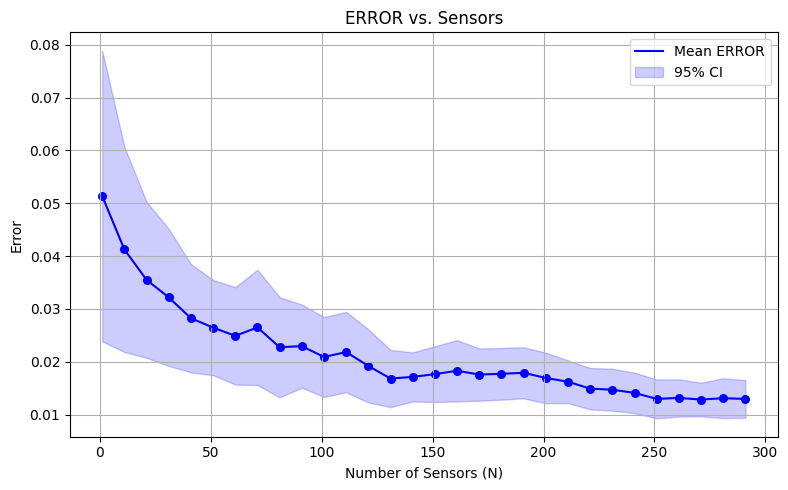

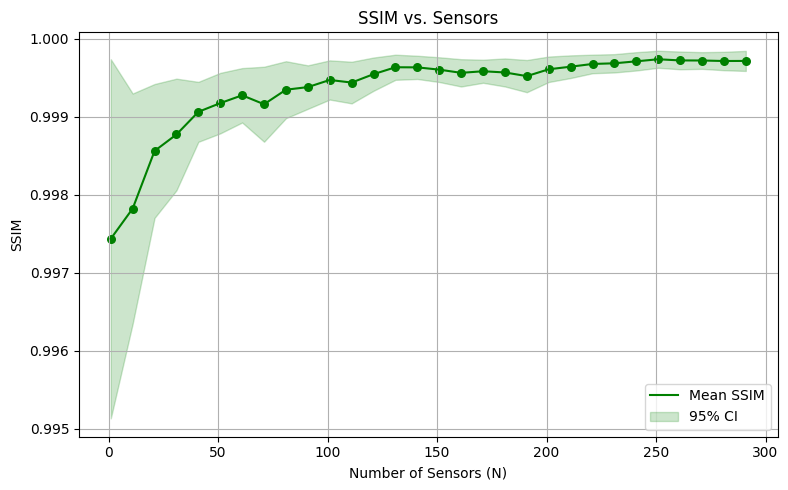

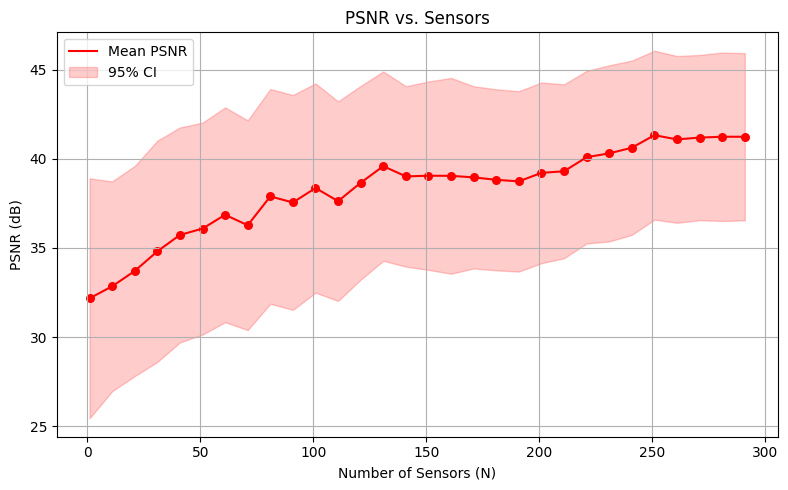

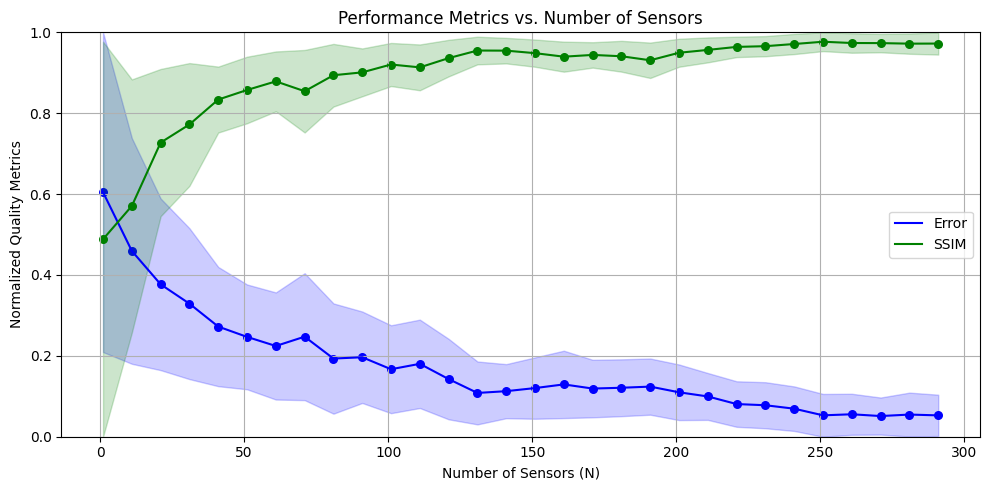

In [ ]:
sensor_values = np.arange(1, 300, 10)

df = experiment_runner.run_single_slice_experiments(A_tensor, test_tensors, subject_name, slice_number, sensor_values)

plot_analytics(df, plot_type="all")

Single slice wells experiments (slice 10):   0%|          | 0/30 [00:00<?, ?it/s]

[[54, 27]]
1
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice wells experiments (slice 10):   3%|▎         | 1/30 [00:00<00:24,  1.20it/s]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
[[54, 27], [81, 28]]
2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice wells experiments (slice 10):   7%|▋         | 2/30 [00:02<00:36,  1.31s/it]

...

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
[[54, 27], [81, 28], [46, 34], [64, 36], [82, 32], [75, 41], [104, 31], [95, 44], [103, 39], [62, 26], [52, 45], [90, 32], [71, 37], [81, 43], [31, 43], [71, 28], [69, 45], [37, 38], [42, 45], [61, 45], [96, 36], [91, 27], [100, 44], [74, 33], [98, 34], [66, 41], [55, 37], [111, 42], [51, 42]]
29
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


Single slice wells experiments (slice 10):  97%|█████████▋| 29/30 [00:55<00:02,  2.26s/it]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
[[54, 27], [81, 28], [46, 34], [64, 36], [82, 32], [75, 41], [104, 31], [95, 44], [103, 39], [62, 26], [52, 45], [90, 32], [71, 37], [81, 43], [31, 43], [71, 28], [69, 45], [37, 38], [42, 45], [61, 45], [96, 36], [91, 27], [100, 44], [74, 33], [98, 34], [66, 41], [55, 37], [111, 42], [51, 42], [44, 41]]
30
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2
Reconstructed tensor shape: torch.Size([139, 48]), m

Single slice wells experiments (slice 10): 100%|██████████| 30/30 [00:58<00:00,  1.94s/it]

Reconstructed tensor shape: torch.Size([139, 48]), mode used: 2


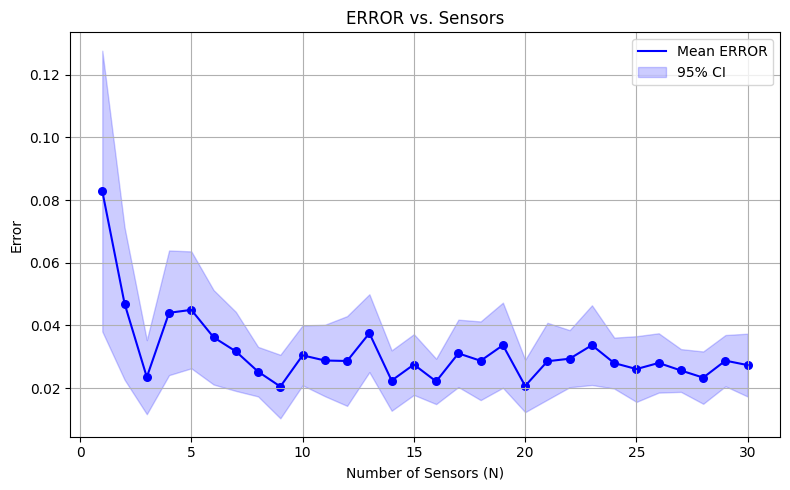

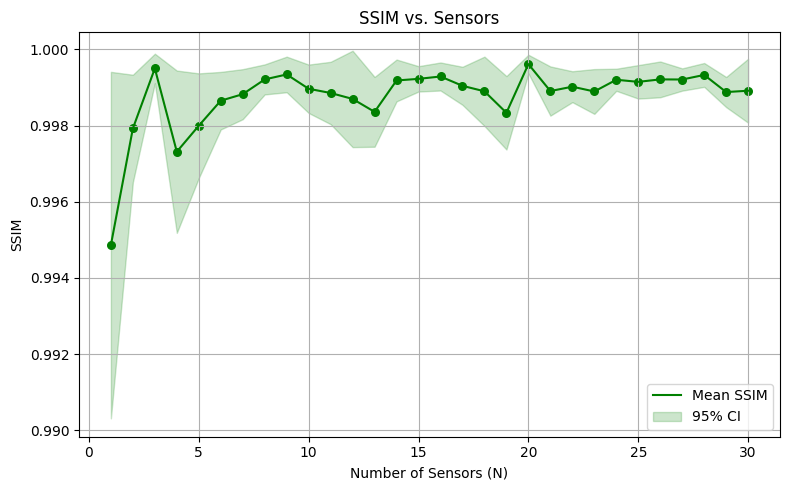

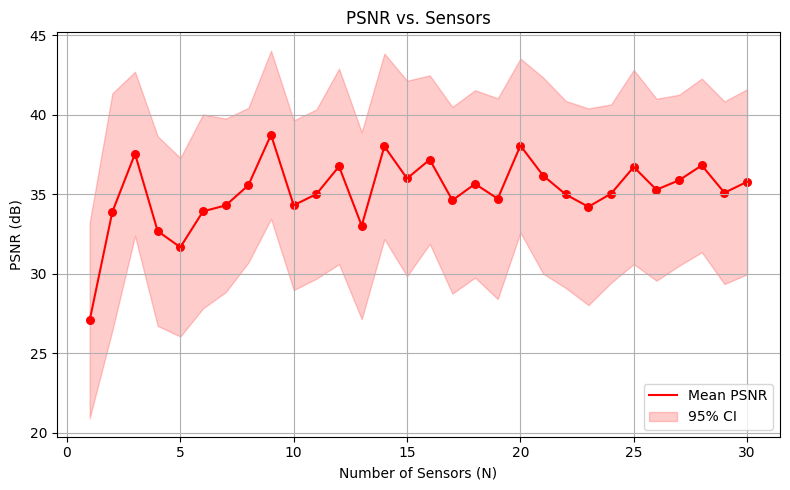

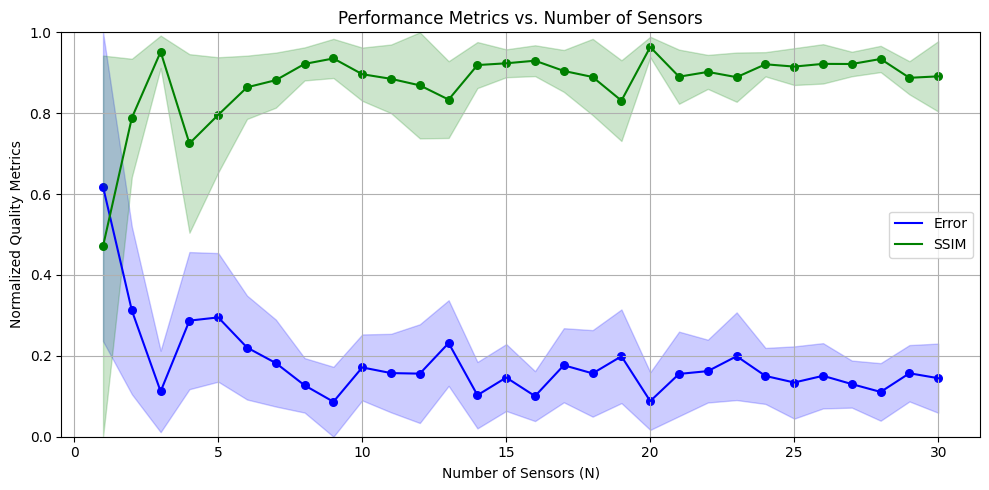

In [ ]:
sensor_values = np.arange(1, 31)    

df = experiment_runner.run_single_slice_wells_experiments(A_tensor, test_tensors, subject_name, slice_number, sensor_values)

plot_analytics(df, plot_type="all")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Эта ячейка сгенерирует и отобразит результаты реконструкции для указанного набора количества сенсоров.
# # Предполагается, что все необходимые функции (TBMD_solver, generate_random_sensors, add_noise,
# # inverse_normalization, plot_two_matrices, calculate_error_and_ssim) и переменные 
# # (X, A_tensor, slice_number, BG, normalization_method, minmax_params, solver_method, 
# # max_iter, epsilon, lambd, delta_0, delta_max, device, SEED, noise_level)
# # уже определены в области видимости ноутбука.

# sensor_counts_to_visualize = [2, 10, 50, 100, 200]

# # X - это уже нормализованный исходный срез (A_tensor[:, :, slice_number] после нормализации)
# # Используем X напрямую как эталонный нормализованный срез.

# print(f"Генерация реконструкций для среза {slice_number} с различным количеством сенсоров.\n")

# # Исходный нормализованный срез для сравнения (это переменная X из предыдущих ячеек)
# X_original_normalized = X

# for i, num_sensors in enumerate(sensor_counts_to_visualize):
#     print(f"--- Обработка для {num_sensors} сенсоров ---")
    
#     # Используем SEED для воспроизводимости, варьируя его для каждого количества сенсоров,
#     # чтобы получить разные (но воспроизводимые) наборы сенсоров и шума.

#     # 1. Генерация местоположений сенсоров
#     # Предполагаем, что X (нормализованный срез) имеет правильную форму.
#     # valid_mask=None используется в соответствии с вызовом run_experiments_single_slice в ячейке 64.
#     qr_decomp = TensorTubeQRDecomposition(
#         tensor=A_tensor,
#         N=num_sensors,
#         rejection_domain=None,
#         check_orthogonality=False,
#         uniform_distribution=True,
#         device='mps',   # 'cpu' or 'cuda' or 'mps'
#         random_state=SEED

#     )
#     P, Q, R = qr_decomp.factorize()
    
#     # 2. Симуляция измерений сенсоров из исходного нормализованного среза X
#     # Убедимся, что sensor_locations являются валидными индексами для X.
#     # Функция generate_random_sensors должна возвращать валидные индексы.
#     # Защитное отсечение индексов (на всякий случай, хотя в идеале не требуется):
#     # sensor_locations[:, 0] = np.clip(sensor_locations[:, 0], 0, X_original_normalized.shape[0] - 1)
#     # sensor_locations[:, 1] = np.clip(sensor_locations[:, 1], 0, X_original_normalized.shape[1] - 1)
    
#     cs_solver = TensorCompressiveSensing(
#         A=A_tensor,
#         P=P,
#         Y=Y,
#         max_iter=max_iter,
#         epsilon=epsilon,
#         lambd=lambd,
#         delta_0=delta_0,
#         delta_max=delta_max,
#         solver_method=solver_method,
#         device="cpu"   # 'cpu' or 'cuda' or 'mps'
#     )
#     x_hat = cs_solver.solve()
    
#     # 3. Добавление шума к измерениям
#     # Предполагается, что функция add_noise доступна.
#     X_reconstructed = reconstruct_tensor(A_tensor=A_tensor, x_hat=x_hat)
    
#     # 5. Обратная нормализация исходного и реконструированного срезов
#     # Исходный срез (денормализованный)
#     original_X = inverse_normalization(X, normalization_method=normalization_method, global_params=minmax_params, background_value=BG)
#     original_X_reconstructed = inverse_normalization(X_reconstructed, normalization_method=normalization_method, global_params=minmax_params, background_value=BG)
        
#     # 6. Отображение результатов
#     # Предполагается, что функция plot_two_matrices доступна.
#     plot_two_matrices(
#         original_X, 
#         original_X_reconstructed, zmin=103, titles=("Original", f"Reconstructed. Sensors = {num_sensors}")
#     )
#     plt.show()
    
# print("Завершено создание реконструкций для указанных количеств сенсоров.")
